# LiH 基态能量求解教程

## 背景与动机
对于大分子基态能量问题的求解，传统量子模拟方法需要消耗大量量子比特资源，文献《Doubling the size of quantum simulators by entanglement forging》提出了一种思路：先对基态做 Schmidt 分解，从而把需要处理的有效维度降低一半。比如对 10 比特的水分子，Schmidt 分解可将其等效为两个 5 比特子系统，这样后续计算只需在 5 比特线路上完成。

## 方法概述
这个案例将使用一个三比特光量子电路去求解，原本需要六比特表示的 LiH 分子基态能量。
采用的一元编码会把光学模式（qumode）映射到等效的qubit计算空间。下面按步骤展开：

### 1) Schmidt 分解与参数化表示
1. 选定三个 Schmidt 基矢进行 Schmidt 分解（取 $n=3$）。此时，六比特基态 $\psi_6$ 可写成：

$$\psi_6 =  \sum_n \lambda_n{U\psi_3^n\otimes V \psi_3^n}$$

这里 $U$ 与 $V$ 表示两个不同的量子电路 Ansatz。为了降低参数量，也可以先取 $U=V$。

### 2) 哈密顿量分解与期望值重构
2. 把 LiH 的哈密顿量写成 Pauli 基矢的线性组合：$H=\sum_k w_k O_k$，其中 $w_k$ 是分解系数。则哈密顿量期望值满足：
$$ <H> = \sum_k w_k <O_k> $$

在这里，每个 Pauli 基矢对应一个 6 比特算符（例如 `IIIZZZ`）。
接着把它切分成两个 3 比特算符 $O_a$ 与 $O_b$，使得 $O_k=O_a\otimes O_b$。
然后分别用 $U\psi_3^n$ 与 $V\psi_3^n$ 计算对应子系统上的算符期望值。

$$<O> = <O_a><O_b> = \sum_{nm} \lambda_n \lambda_m <\psi_3^n|U^+O_a U|\psi_3^n><\psi_3^n|V^+O_b V|\psi_3^n>  = \vec{\lambda}^T M \vec{\lambda}$$

其中
$\vec{\lambda}=(\lambda_1, \lambda_2, \lambda_3)， ||\vec{\lambda}||=1$， $M=\begin{pmatrix}
M_{00} & M_{01} & M_{02}\\
M_{10} & M_{11} & M_{12} \\
M_{20} & M_{21} & M_{22}
\end{pmatrix}$， 其中$M_{ij}=<\psi_3^i|U^+O_a U|\psi_3^j><\psi_3^i|V^+O_b V|\psi_3^j>$。由于哈密顿量是厄米算符，可以得到 $M$ 的厄米性：$M^\dagger = M$（其中 $\dagger$ 表示转置并取共轭）。

### 3) 最小特征值与基态能量
3. 把所有算符的期望值按分解系数求和，可得到
$M_{sum}=\sum_k w_k M_k$。
于是哈密顿量的期望值可以写成二次型：$\langle H\rangle = \vec{\lambda}^T M_{sum} \vec{\lambda}$。
在约束 $||\vec{\lambda}||=1$ 下，这个二次型的最小值等于矩阵 $M_{sum}$ 的最小特征值；对应的 $\vec{\lambda}$ 就是该特征值的特征向量。因此，最小特征值也对应于哈密顿量的基态能量。

## 构建期望值计算线路
首先搭建一个 `Clements` 光量子电路。它采用一元编码将光学模式等效成可计算的量子比特，使得在前向计算中可以得到任意 Pauli 基矢算符的期望值。

In [ ]:
import pickle
from functools import reduce
from itertools import product

import deepquantum as dq
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as nnf
from torch import nn


class QumodeExpectValue(nn.Module):
    # 使用Clements线路计算算符的平均值
    def __init__(self, nmode, init_state=None, if_sup=False, u_sup=None, loss=None):
        super().__init__()
        if init_state is None:
            init_state = [1] + [0] * (nmode - 1)
        # 一元编码
        cir = dq.Clements(nmode=nmode, init_state=init_state, cutoff=2)
        if loss is not None:
            for k in range(nmode):
                cir.loss_db(k, loss)
        cir.set_fock_basis()
        nqubit = int(torch.log2(torch.tensor(nmode)))
        basis_list = torch.tensor(list(product(range(2), repeat=nqubit)))
        # 考虑初始态是不是叠加态
        u_start = torch.eye(cir.nmode) if not if_sup else u_sup
        u_start = u_start.to(dtype=torch.complex64)
        self.cir = cir
        self.nmode = nmode
        self.init_state = init_state
        self.basis_list = basis_list
        self.u_start = u_start
        self.if_sup = if_sup
        self.ndata = cir.ndata
        self.loss = loss

    def forward(self, data=None, op=None, u_measure=None, idx_z=None, shots=None):
        """Obtain expectation value for given operator using single-rail encoding"""
        cir = self.cir
        basis_list = self.basis_list
        state = self.init_state
        u_start = self.u_start

        if u_measure is None:
            u_measure, idx_z = self.get_u_measure(op)
        if not isinstance(idx_z, torch.Tensor):
            idx_z = torch.tensor(idx_z).unsqueeze(0)
        if u_measure.ndim == 2:
            u_measure = u_measure.unsqueeze(0)

        if self.loss is not None:
            # 带loss情况下计算维度加倍
            u_measure_loss = torch.eye(2 * self.nmode).repeat(u_measure.shape[0], 1, 1)
            u_start_loss = torch.eye(2 * self.nmode)
            u_measure_loss = u_measure_loss.to(dtype=torch.complex64)
            u_start_loss = u_start_loss.to(dtype=torch.complex64)
            u_measure_loss[:, : self.nmode, : self.nmode] = u_measure
            u_start_loss[: self.nmode, : self.nmode] = u_start
            u_total = u_measure_loss @ cir(data=data) @ u_start_loss
        else:
            u_total = u_measure @ cir(data=data) @ u_start
        if u_total.ndim == 2:
            u_total = u_total.unsqueeze(0)
        idx = torch.nonzero(state)[0][0]
        # 根据取行列规则，一元编码只需要取酉矩阵的一行(列)即可
        state = u_total[:, :, idx]
        if shots is None:
            probs = (abs(state) ** 2)[:, : self.nmode]
        else:
            probs = sample(abs(state) ** 2, shots)
            probs = probs[:, : self.nmode]
        norm = torch.sum(probs, dim=1)
        # 概率归一化
        probs = probs / (norm + 1e-10).unsqueeze(-1)
        # False 时对应的列变成0，然后求和
        masked_basis = basis_list.unsqueeze(0) * idx_z.unsqueeze(1)
        parity_sum = masked_basis.sum(dim=-1)
        temp_coeff = torch.tensor(-1) ** parity_sum
        return (probs.squeeze() * temp_coeff).sum(-1)

    @staticmethod
    def get_u_measure(op):
        idx_z = []
        u_list = []
        x_rotate_gate = torch.tensor([[0.7071 + 0.0j, 0.7071 + 0.0j], [0.7071 + 0.0j, -0.7071 - 0.0j]])
        y_rotate_gate = torch.tensor([[0.7071 + 0.0000j, 0.0000 - 0.7071j], [0.7071 + 0.0000j, 0.0000 + 0.7071j]])
        iden2 = torch.eye(2, dtype=x_rotate_gate.dtype)
        # 处理每个qubit的Pauli算符，旋转到Z基进行测量
        for k in range(len(op)):
            op_k = op[k]
            if op_k == 'I':
                u_list.append(iden2)
                idx_z.append(False)
            elif op_k == 'Z':
                idx_z.append(True)
                u_list.append(iden2)
            elif op_k == 'X':
                # X算符：通过H门旋转到Z基 (H X H† = Z)
                idx_z.append(True)
                u_list.append(x_rotate_gate)
            elif op_k == 'Y':
                # Y算符：通过S†H旋转到Z基 ((S†H) Y (H†S) = Z)
                idx_z.append(True)
                u_list.append(y_rotate_gate)
        u_measure = reduce(torch.kron, u_list)
        return u_measure, idx_z


# 提前计算各个算符的测量变换基矢
def get_measure_u(pauli_list_full):
    u_measure_list_q3 = []
    idx_z_list_q3 = []

    pauli_coef = []
    len_ = len(pauli_list_full)
    for i in range(len_):
        pauli_coef.append(pauli_list_full[i][-1])
        temp_op1 = pauli_list_full[i][:3]
        temp_op2 = pauli_list_full[i][3:6]
        temp_u_q3 = []
        temp_idx_q3 = []

        for op in [temp_op1, temp_op2]:
            temp_q3 = QumodeExpectValue.get_u_measure(op)
            temp_u_q3.append(temp_q3[0])
            temp_idx_q3.append(temp_q3[1])

        u_measure_list_q3.append(torch.stack(temp_u_q3))
        idx_z_list_q3.append(torch.tensor(temp_idx_q3))

    u_measure_list_q3_ts = torch.stack(u_measure_list_q3)
    idx_z_list_q3_ts = torch.stack(idx_z_list_q3)
    return u_measure_list_q3_ts, idx_z_list_q3_ts, pauli_coef


# 保持梯度的采样方法
def sample(probs, shots):
    eps = 1e-20
    logits = torch.log(probs + eps)
    logits_expanded = logits.unsqueeze(1).expand(-1, shots, -1)
    samples = nnf.gumbel_softmax(logits_expanded, tau=0.01, hard=True)
    sampled_probs = samples.mean(dim=1)
    return sampled_probs

In [14]:
# 测试算符平均值计算
torch.manual_seed(12)
data = nn.Parameter(torch.rand(64))
init_state = torch.tensor([1] + [0] * 7)
qv_test = QumodeExpectValue(nmode=8, init_state=init_state, loss=None)
re = qv_test(data, op='YYY', shots=None)
print(re)

tensor([-0.0533], grad_fn=<SumBackward1>)


## 加载哈密顿量分解数据
载入哈密顿量在 Pauli 基底上的分解数据。该例中总共分解出 62 个基矢；每个基矢对应一个 6 比特的 Pauli 算符字符串（例如 `IIIZZZ` 这类张量积算符）。

In [5]:
## load 数据
radius = 0.1

with open(f'data_lih/LiH_data_{radius}.pkl', 'rb') as f:
    dic = pickle.load(f)
constant = dic['constant']
pauli_list_full = dic['pauli_list']
energy_full = dic['fci_energy']

print(len(pauli_list_full), pauli_list_full[0])

62 ['I', 'I', 'I', 'I', 'I', 'I', np.complex128(-0.558829025352944+0j)]


## 预计算测量变换
接下来计算哈密顿量的平均值。
为了提高计算效率，我们把“测量步骤”提前做成可复用的量：对每个算符预先计算其测量变换（把相应的 Pauli 算符旋转到 Z 基）以及 Z 算符在测量中的位置。
因此得到的测量变换矩阵张量形状为 `(62, 2, 8, 8)`：`62` 表示泡利基矢组合的数量，`2` 表示两个三比特子系统，每个子系统对应的矩阵维度为 $8\times 8$。

In [ ]:
u_measure_list_q3_ts, idx_z_list_q3_ts, pauli_coef = get_measure_u(pauli_list_full)
print(u_measure_list_q3_ts.shape, idx_z_list_q3_ts.shape)

(torch.Size([62, 2, 8, 8]), torch.Size([62, 2, 3]))

## 非对角项期望值与叠加态制备
接下来计算每个 Pauli 算符的平均值。
因为不同算符的计算结构高度相似，我们使用 batch 处理并行加速求期望。

### 选取 Schmidt 基矢
接下来我们从 Schmidt 分解中选取 3 个基矢：$\ket{110}$、$\ket{101}$ 和 $\ket{011}$。

### 非对角元的重构公式
- 为了计算非对角元 $<\psi_i|O|\psi_j>$（$i\neq j$），我们需要制备下面两种叠加态：
  $$\psi_{R} = \frac{\sqrt{2}}{2}(\psi_i + \psi_j),\quad \psi_{I} = \frac{\sqrt{2}}{2}(\psi_i + i * \psi_j)$$
$<\psi_i|O|\psi_j>$ 可以表示为下面的平均值的线性组合，
$$<\psi_i|O|\psi_j> = (O_{RR}-0.5*(O_{ii} + O_{jj})) + i *(0.5*(O_{ii} + O_{jj}) - O_{II}) $$
$$O_{RR} = <\psi_R|O|\psi_R>，O_{II} = <\psi_I|O|\psi_I>，O_{ii} = <\psi_i|O|\psi_i>，O_{jj} = <\psi_j|O|\psi_j>$$

### 叠加态制备门序列
对于叠加态 $\psi_{R}$ 和 $\psi_{I}$ 的制备：在光量子电路中，我们通常先制备一个 Fock 初态，然后再作用“叠加态变换矩阵”，即可得到相应的叠加态。
在实现中，这个叠加态变换往往可以与后续 Ansatz 的酉变换合并，从而减少电路深度。
下面给出 6 个叠加态所对应的构造顺序。涉及的基本门 $H$、$S$、$SWAP$、$CNOT$ 的矩阵形式如下。
$$
H = \frac{\sqrt{2}}{2}\begin{pmatrix}
1 & 1\\
1 & -1
\end{pmatrix},
S = \frac{\sqrt{2}}{2}\begin{pmatrix}
1 & 1\\
1 & i
\end{pmatrix},
SWAP=\begin{pmatrix}
1 & 0 & 0 & 0\\
0 & 0 & 1 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1
\end{pmatrix},
CNOT=\begin{pmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0
\end{pmatrix}
$$

- ($\ket{110}$, $\ket{101}$):

线路初态：$\ket{110}$

$\psi_{R} = \frac{\sqrt{2}}{2}(\ket{110} + \ket{101}),\psi_{I} = \frac{\sqrt{2}}{2}(\ket{110} + i * \ket{101})$

$H(2) \ket{110} --> \frac{\sqrt{2}}{2}(\ket{110} + \ket{111})$,

$SWAP (1,2) --> \frac{\sqrt{2}}{2}(\ket{101} + \ket{111})$,

$CNOT (1,2) --> \frac{\sqrt{2}}{2}(\ket{101} + \ket{110})$,

$S(2) --> \frac{\sqrt{2}}{2}(\ket{110} + i * \ket{101})$

- ($\ket{110}$, $\ket{011}$):

线路初态：$\ket{110}$

$\psi_{R} = \frac{\sqrt{2}}{2}(\ket{110} + \ket{011}),\psi_{I} = \frac{\sqrt{2}}{2}(\ket{110} + i * \ket{011})$

$H(2) \ket{110} --> \frac{\sqrt{2}}{2}(\ket{110} + \ket{111})$,

$SWAP (1,2) --> \frac{\sqrt{2}}{2}(\ket{101} + \ket{111})$,

$CNOT (1,2) --> \frac{\sqrt{2}}{2}(\ket{101} + \ket{110})$,

$SWAP (0,1)--> \frac{\sqrt{2}}{2}(\ket{110} + \ket{011})$,

$S (2) --> \frac{\sqrt{2}}{2}(\ket{110} + i * \ket{011})$

- ($\ket{101}$, $\ket{011}$):

线路初态：$\ket{101}$

$\psi_{R} = \frac{\sqrt{2}}{2}(\ket{101} + \ket{011}),\psi_{I} = \frac{\sqrt{2}}{2}(\ket{101} + i * \ket{011})$

$H(1) \ket{101} --> \frac{\sqrt{2}}{2}(\ket{101} + \ket{111})$,

$SWAP (0,1) --> \frac{\sqrt{2}}{2}(\ket{011} + \ket{111})$,

$CNOT (0,1) --> \frac{\sqrt{2}}{2}(\ket{011} + \ket{101})$,

$S (1) --> \frac{\sqrt{2}}{2}(\ket{101} + i * \ket{011})$

下面开始计算叠加态制备酉矩阵。

In [7]:
## 构建三比特系统的三个初始量子态110， 101， 011，以及他们的叠加态
u_state = torch.tensor([0.0, 1.0])
d_state = torch.tensor([1.0, 0.0])
state1 = reduce(torch.kron, [u_state, u_state, d_state])
state2 = reduce(torch.kron, [u_state, d_state, u_state])
state3 = reduce(torch.kron, [d_state, u_state, u_state])
state = torch.stack([state1, state2, state3])

## 构建子系统的初始量子态
# 在八模线路中分别一元编码映射qubit
state_sub3 = torch.stack([state1.to(int), state2.to(int), state3.to(int)])

# 求解制备叠加态酉矩阵
# 110 --> sqrt(2)/2*(110+101)
# 110 --> sqrt(2)/2*(110+011)
# 101 --> sqrt(2)/2*(101+011)
state_sup = [state1.to(int), state1.to(int), state2.to(int)]

h_mat = torch.tensor([[1, 1], [1, -1]]) * np.sqrt(2) / 2 + 0j
x_mat = torch.tensor([[0.0, 1.0], [1.0, 0.0]]) + 0j
s_mat = torch.tensor([[1.0, 0.0], [0.0, 1j]]) + 0j
cnot_mat = torch.tensor([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]]) + 0j
swap_mat = torch.tensor([[1, 0, 0, 0], [0, 0, 1, 0], [0, 1, 0, 0], [0, 0, 0, 1]]) + 0j
iden2 = torch.eye(2)

temp1_real = torch.kron(iden2, cnot_mat) @ torch.kron(iden2, swap_mat) @ reduce(torch.kron, [iden2, iden2, h_mat])
temp1_imag = reduce(torch.kron, [iden2, iden2, s_mat]) @ temp1_real

temp2_real = torch.kron(swap_mat, iden2) @ temp1_real
temp2_imag = reduce(torch.kron, [iden2, iden2, s_mat]) @ temp2_real

temp3_real = torch.kron(cnot_mat, iden2) @ torch.kron(swap_mat, iden2) @ reduce(torch.kron, [iden2, h_mat, iden2])
temp3_imag = reduce(torch.kron, [iden2, s_mat, iden2]) @ temp3_real

u_list_sup = [temp1_real, temp2_real, temp3_real, temp1_imag, temp2_imag, temp3_imag]
u_state_sup = state_sup + state_sup

## 初始化与形状检查
下面开始做一个初始化测试。
我们分别搭建 3 条线路计算对角项 $M_{ii}$，并搭建 6 条线路计算非对角项 $M_{ij}$。
`loss` 用来调节光损耗强度，单位为 dB。

In [8]:
## 初始化测试
torch.manual_seed(12)
d1 = 64
nmode_q3 = 8
data = torch.rand(d1, requires_grad=True)
loss = None  # dB
# diag
output_q3_diag = []
models_q3_diag = [QumodeExpectValue(nmode=nmode_q3, init_state=state_sub3[k], loss=loss) for k in range(3)]  # schimdt 3
for i in range(len(models_q3_diag)):
    output_q3_diag_i = models_q3_diag[i](
        data=data[:d1], u_measure=u_measure_list_q3_ts.reshape(-1, 8, 8), idx_z=idx_z_list_q3_ts.reshape(-1, 3)
    )
    output_q3_diag.append(output_q3_diag_i)
output_q3_diag = torch.stack(output_q3_diag)
print(output_q3_diag.shape)

# off diag
output_q3_off_diag = []
models_q3_off_diag = [
    QumodeExpectValue(nmode=nmode_q3, init_state=u_state_sup[k], loss=loss, if_sup=True, u_sup=u_list_sup[k])
    for k in range(6)
]  # 包括实部也包括虚部计算 schimdt 3

for i in range(len(models_q3_off_diag)):
    output_q3_off_diag_i = models_q3_off_diag[i](
        data=data[:d1], u_measure=u_measure_list_q3_ts.reshape(-1, 8, 8), idx_z=idx_z_list_q3_ts.reshape(-1, 3)
    )
    output_q3_off_diag.append(output_q3_off_diag_i)
output_q3_off_diag = torch.stack(output_q3_off_diag)
print(output_q3_off_diag.shape)

torch.Size([3, 124])
torch.Size([6, 124])


下面定义一个用于估计基态能量的函数。
它通过调用前面构建的线路来计算哈密顿量中各 Pauli 基矢的贡献，并把结果按 Schmidt 系数与哈密顿量分解系数加权求和，最终返回一个基态能量标量。函数返回基态能量的估计值。参数说明如下，
- `models_q3_diag`：用于计算对角项 $M_{ii}$ 的 3 条线路；
- `models_q3_off_diag`：用于计算非对角项 $M_{ij}$ 的 6 条线路；
- `n_subs`：子系统个数，这里为 2；
- `u_measure_list_q3_ts`：各 Pauli 基矢对应的测量变换矩阵；
- `idx_z_list_q3_ts`：Z 算符在测量设置中的位置；
- `pauli_coef`：哈密顿量分解中各基矢的叠加权重；
- `data`：线路编码的数据（变分参数）；
- `shots`：采样次数（用于带采样的期望值估计）。

In [ ]:
## 定义用于估计基态能量的函数
d1 = 64


def compute_eigen_energy_measure_photonic_lih(
    models_q3_diag, models_q3_off_diag, n_subs, u_measure_list_q3_ts, idx_z_list_q3_ts, pauli_coef, data, shots
):
    output_q3_diag = []
    for i in range(len(models_q3_diag)):
        # print(u_measure_list_q3_ts.shape)
        output_q3_diag_i = models_q3_diag[i](
            data=data[:d1],
            u_measure=u_measure_list_q3_ts.reshape(-1, 8, 8),
            idx_z=idx_z_list_q3_ts.reshape(-1, 3),
            shots=shots,
        )
        output_q3_diag.append(output_q3_diag_i)
    output_q3_diag = torch.stack(output_q3_diag)
    shape1 = output_q3_diag.shape  # (batch, n_subs * n_ops)
    temp1_diag = output_q3_diag.reshape(shape1[0], -1, n_subs)

    temp2_diag = torch.prod(temp1_diag, dim=2)
    diag = (temp2_diag * pauli_coef).sum(dim=1)
    temp1_sub3 = torch.stack(
        [
            output_q3_diag[0] + output_q3_diag[1],
            output_q3_diag[0] + output_q3_diag[2],
            output_q3_diag[1] + output_q3_diag[2],
        ]
    )

    # off diag
    output_q3_off_diag = []
    for i in range(len(models_q3_off_diag)):
        output_q3_off_diag_i = models_q3_off_diag[i](
            data=data[:d1],
            u_measure=u_measure_list_q3_ts.reshape(-1, 8, 8),
            idx_z=idx_z_list_q3_ts.reshape(-1, 3),
            shots=shots,
        )
        output_q3_off_diag.append(output_q3_off_diag_i)
    output_q3_off_diag = torch.stack(output_q3_off_diag)

    shape2 = output_q3_off_diag.shape
    real_ndim = shape2[0] // 2
    temp1_off_diag = (output_q3_off_diag[:real_ndim] - 0.5 * temp1_sub3) + 1j * (
        0.5 * temp1_sub3 - output_q3_off_diag[real_ndim:]
    )
    temp2_off_diag = torch.prod(temp1_off_diag.reshape(shape2[0] // 2, -1, n_subs), dim=2)
    off_diag = (temp2_off_diag * pauli_coef).sum(dim=1)

    h_mat_ob2 = torch.diag_embed(diag)
    rows = [0, 0, 1]
    cols = [1, 2, 2]
    h_mat_ob2[rows, cols] = off_diag
    h_mat_ob2[cols, rows] = off_diag.conj()
    # print(diag, off_diag)
    h_mat_ob2 = h_mat_ob2 + torch.eye(3, device=data.device) * 1e-9
    eigen_value, _ = torch.linalg.eigh(h_mat_ob2)
    return eigen_value[0], h_mat_ob2

## 变分优化实验（无损耗）
下面我们使用“基态能量计算函数”来做梯度变分，从而得到不同核间距下 LiH 的基态能量。
在本节中先不考虑光损耗（`loss` 设为 `None`），便于验证方法本身的正确性。

In [10]:
d1 = 64
nmode_q3 = 8
data = torch.rand(d1, requires_grad=True)
loss_db = None  # dB
# diag
output_q3_diag = []
models_q3_diag = [QumodeExpectValue(nmode=nmode_q3, init_state=state_sub3[k], loss=loss_db) for k in range(3)]
# off diag
output_q3_off_diag = []
models_q3_off_diag = [
    QumodeExpectValue(nmode=nmode_q3, init_state=u_state_sup[k], loss=loss_db, if_sup=True, u_sup=u_list_sup[k])
    for k in range(6)
]  # 包括实部也包括虚部计算

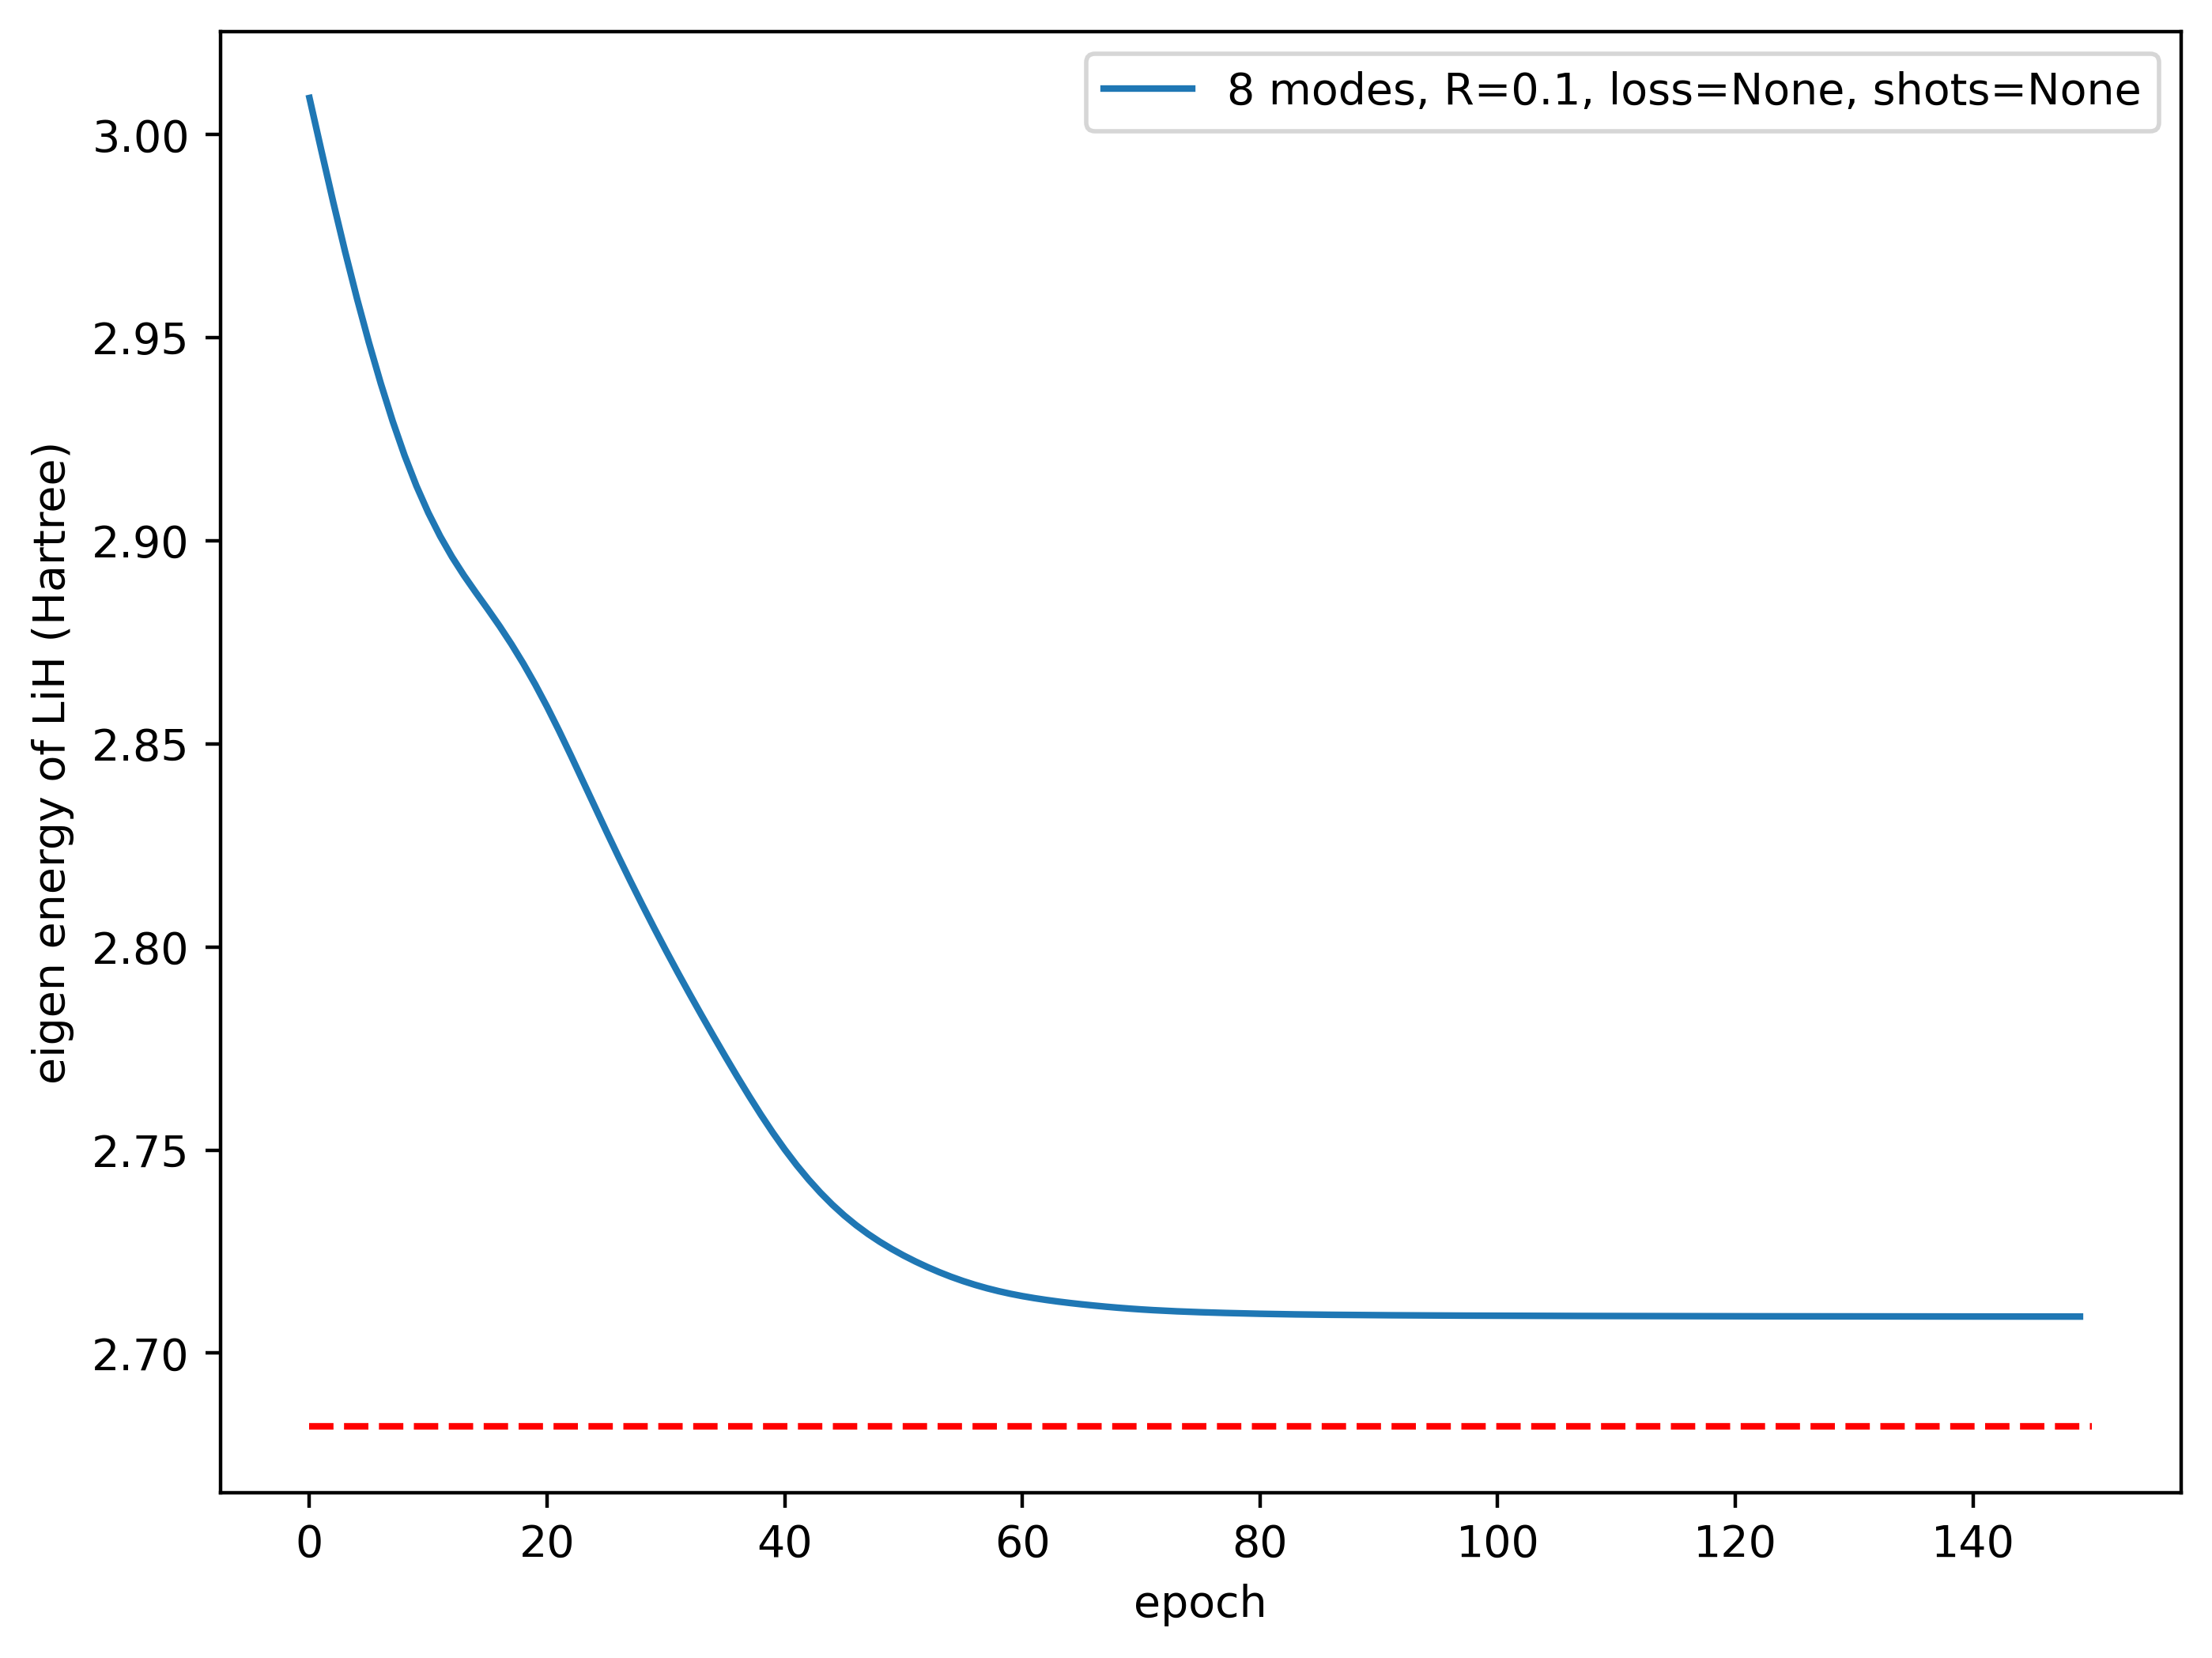

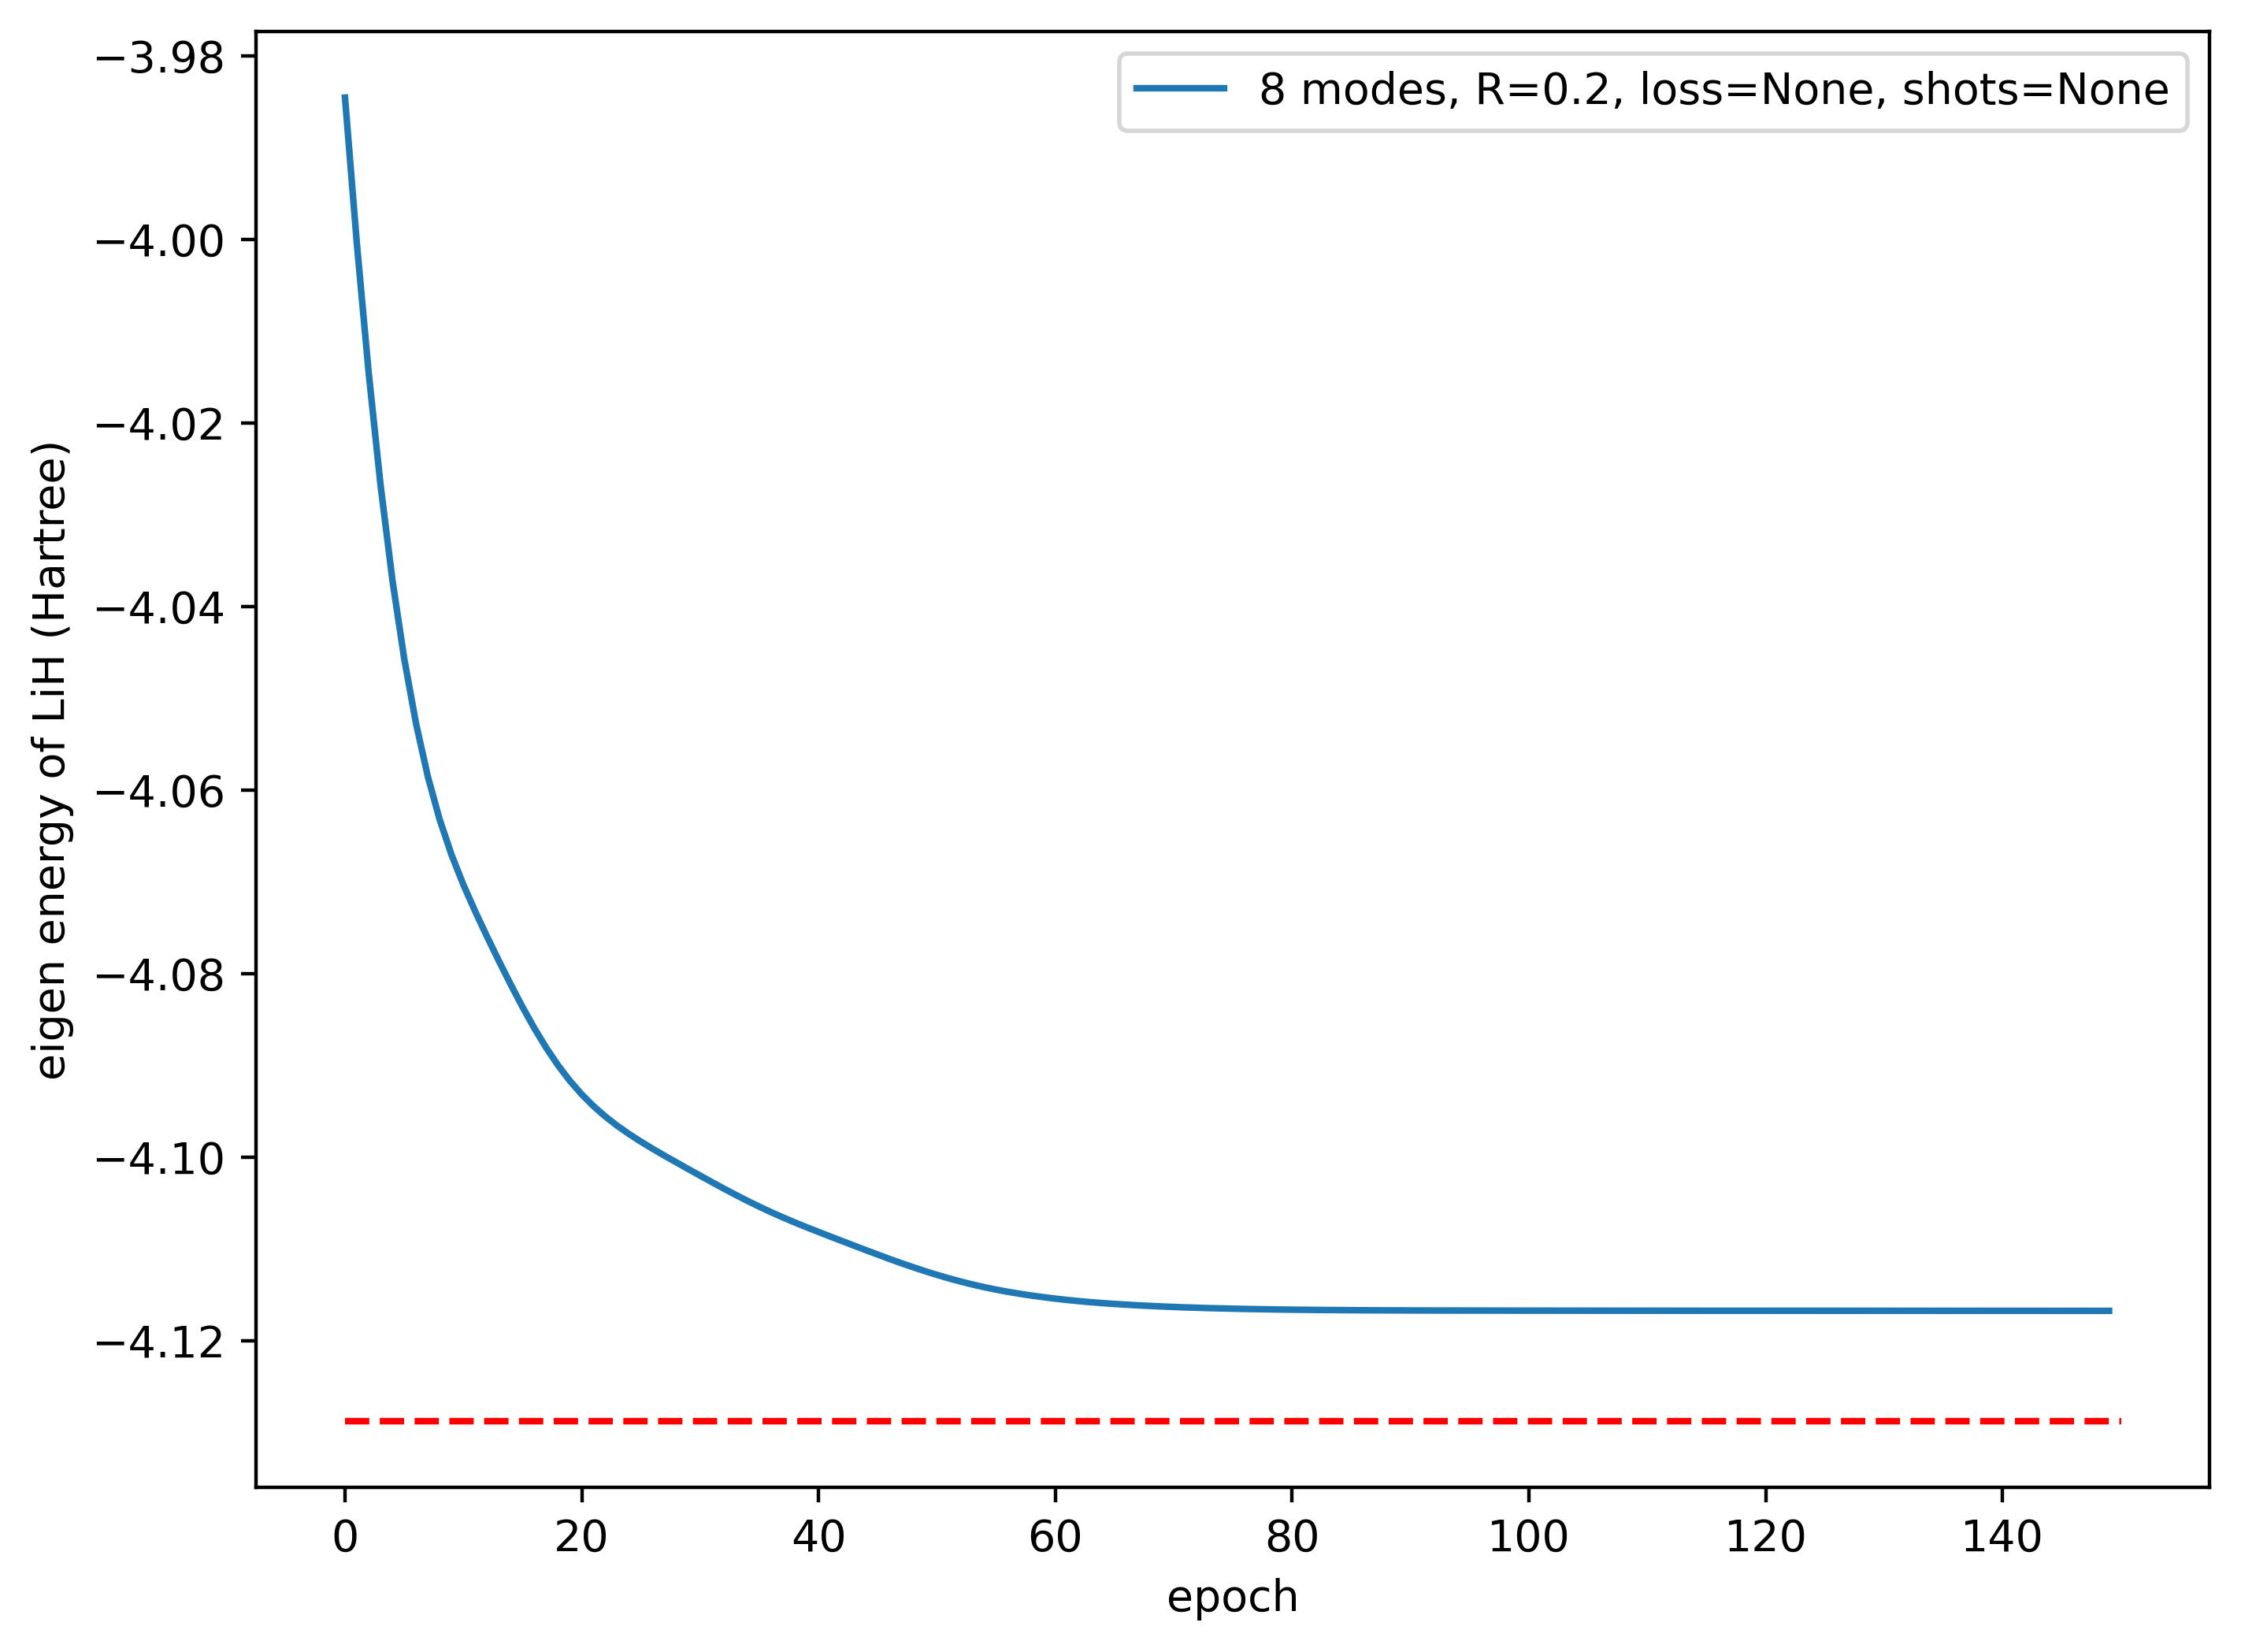

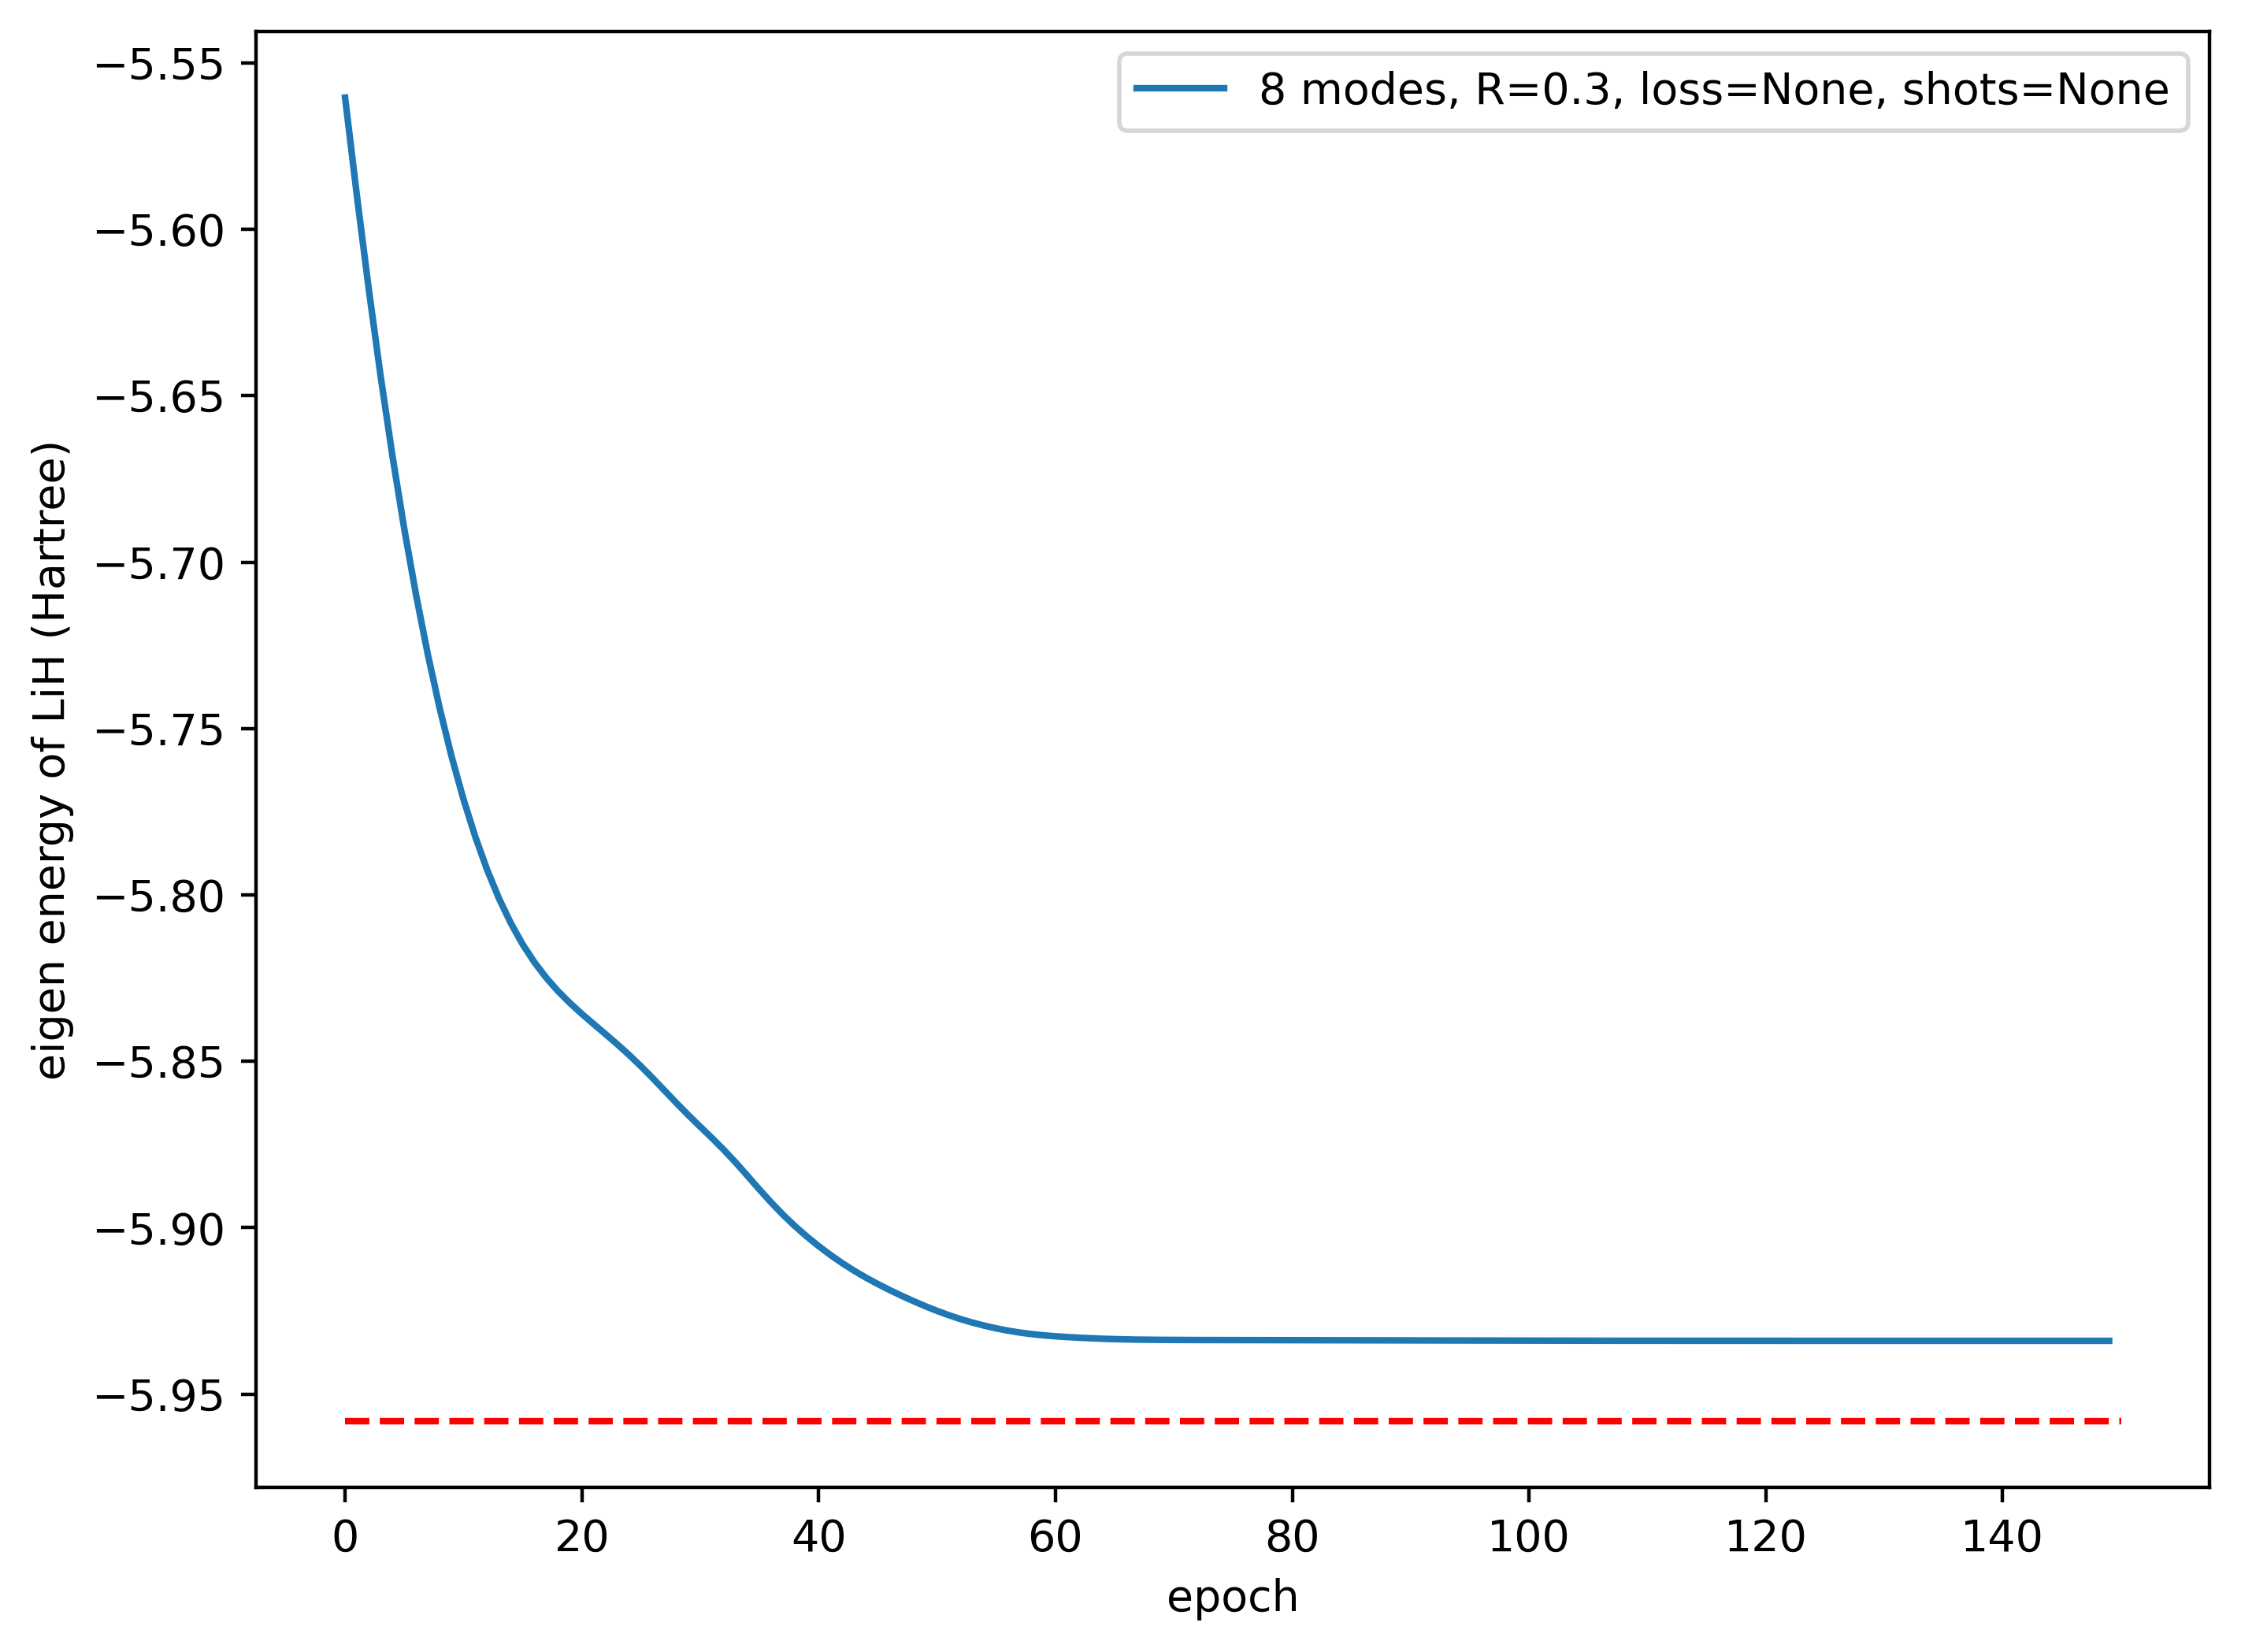

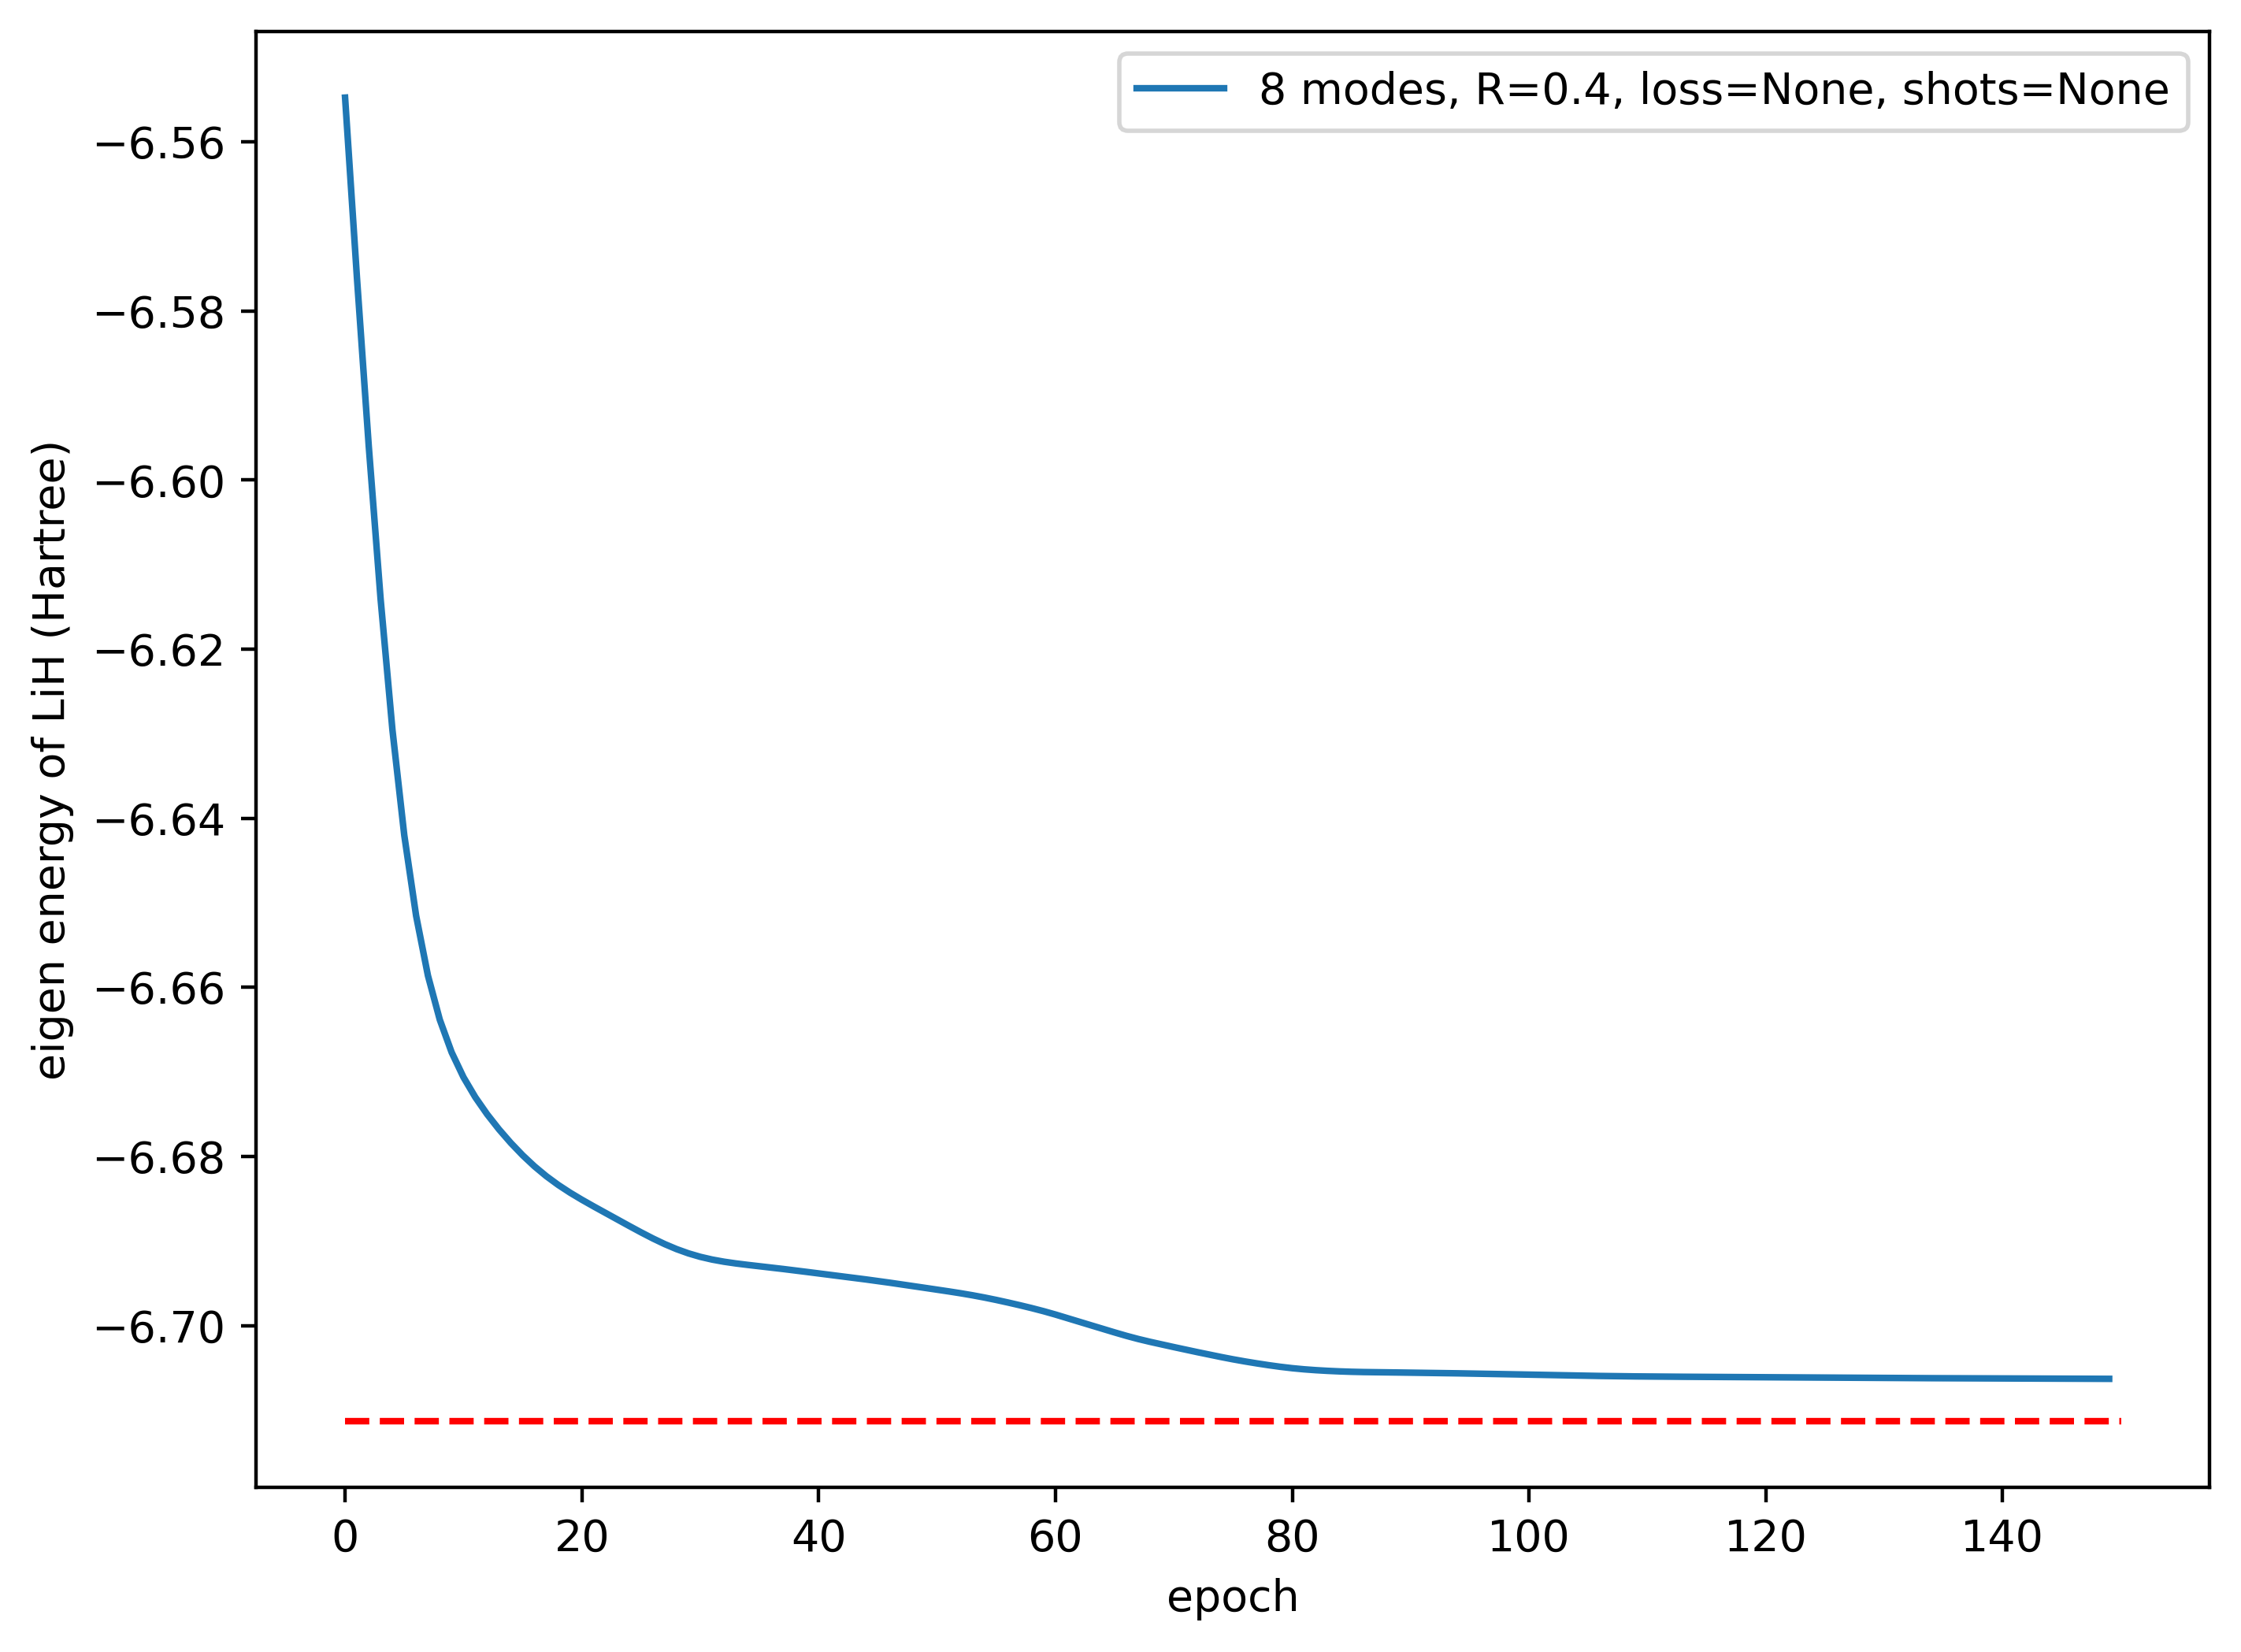

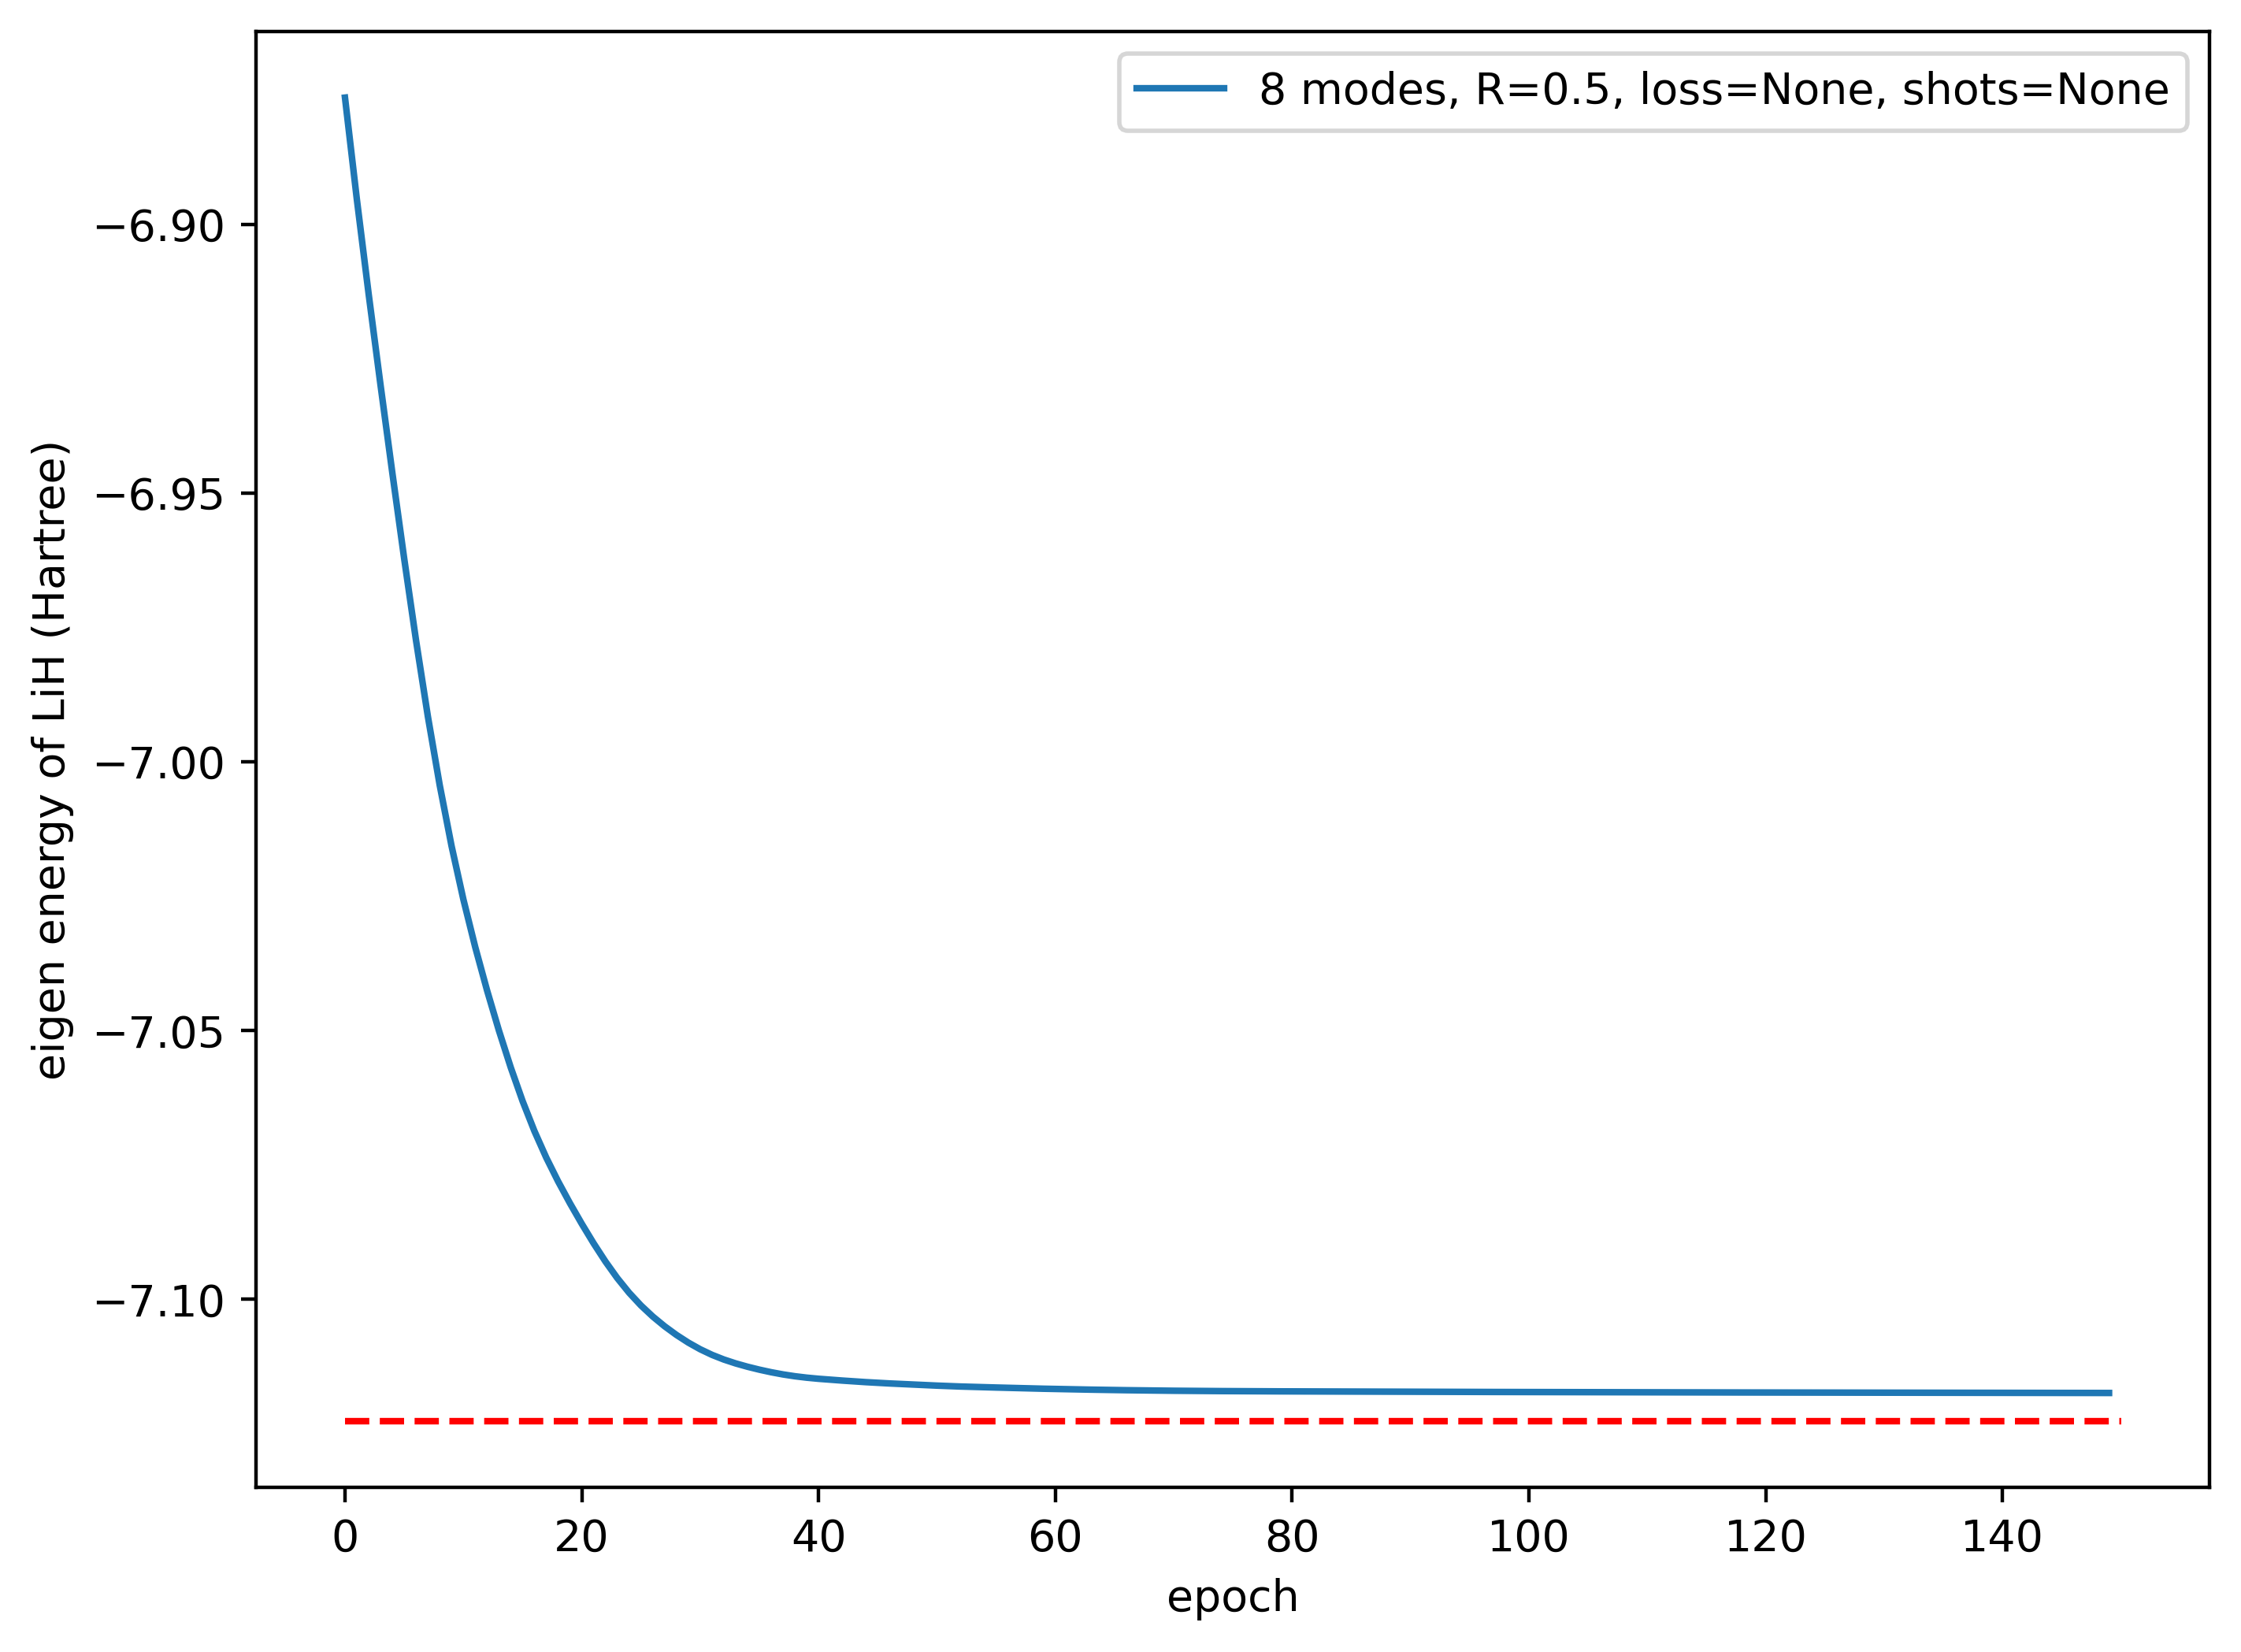

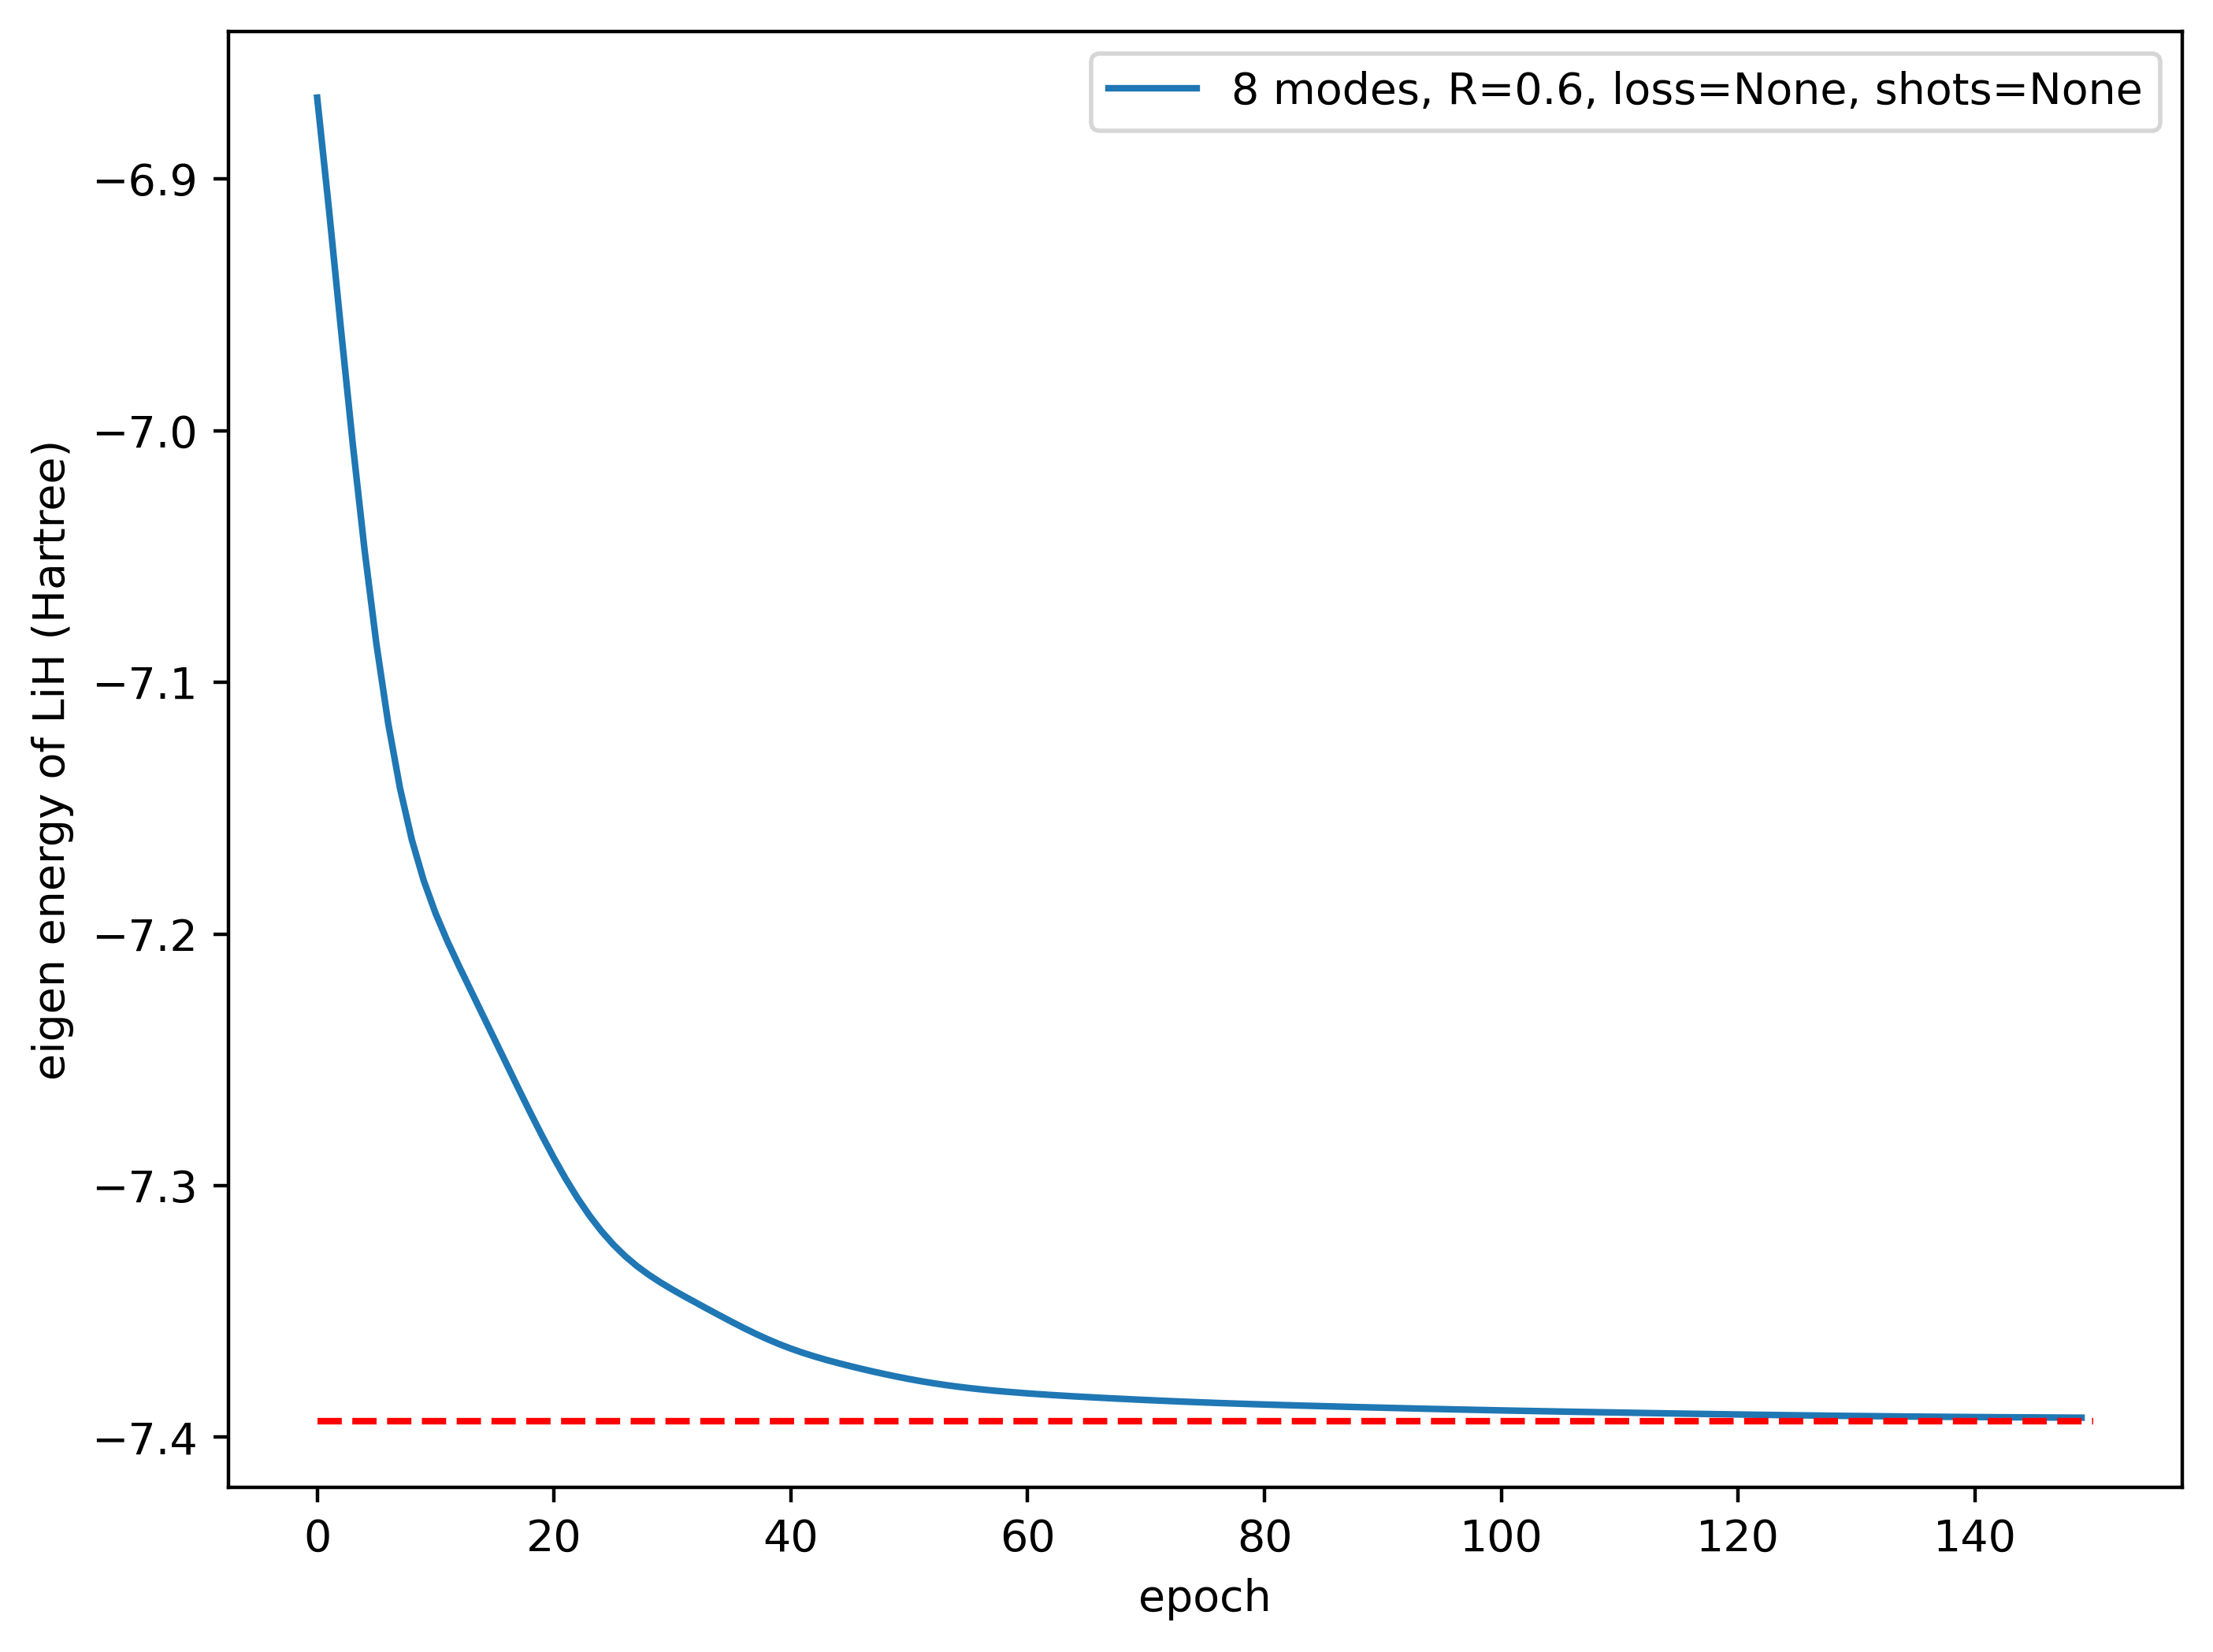

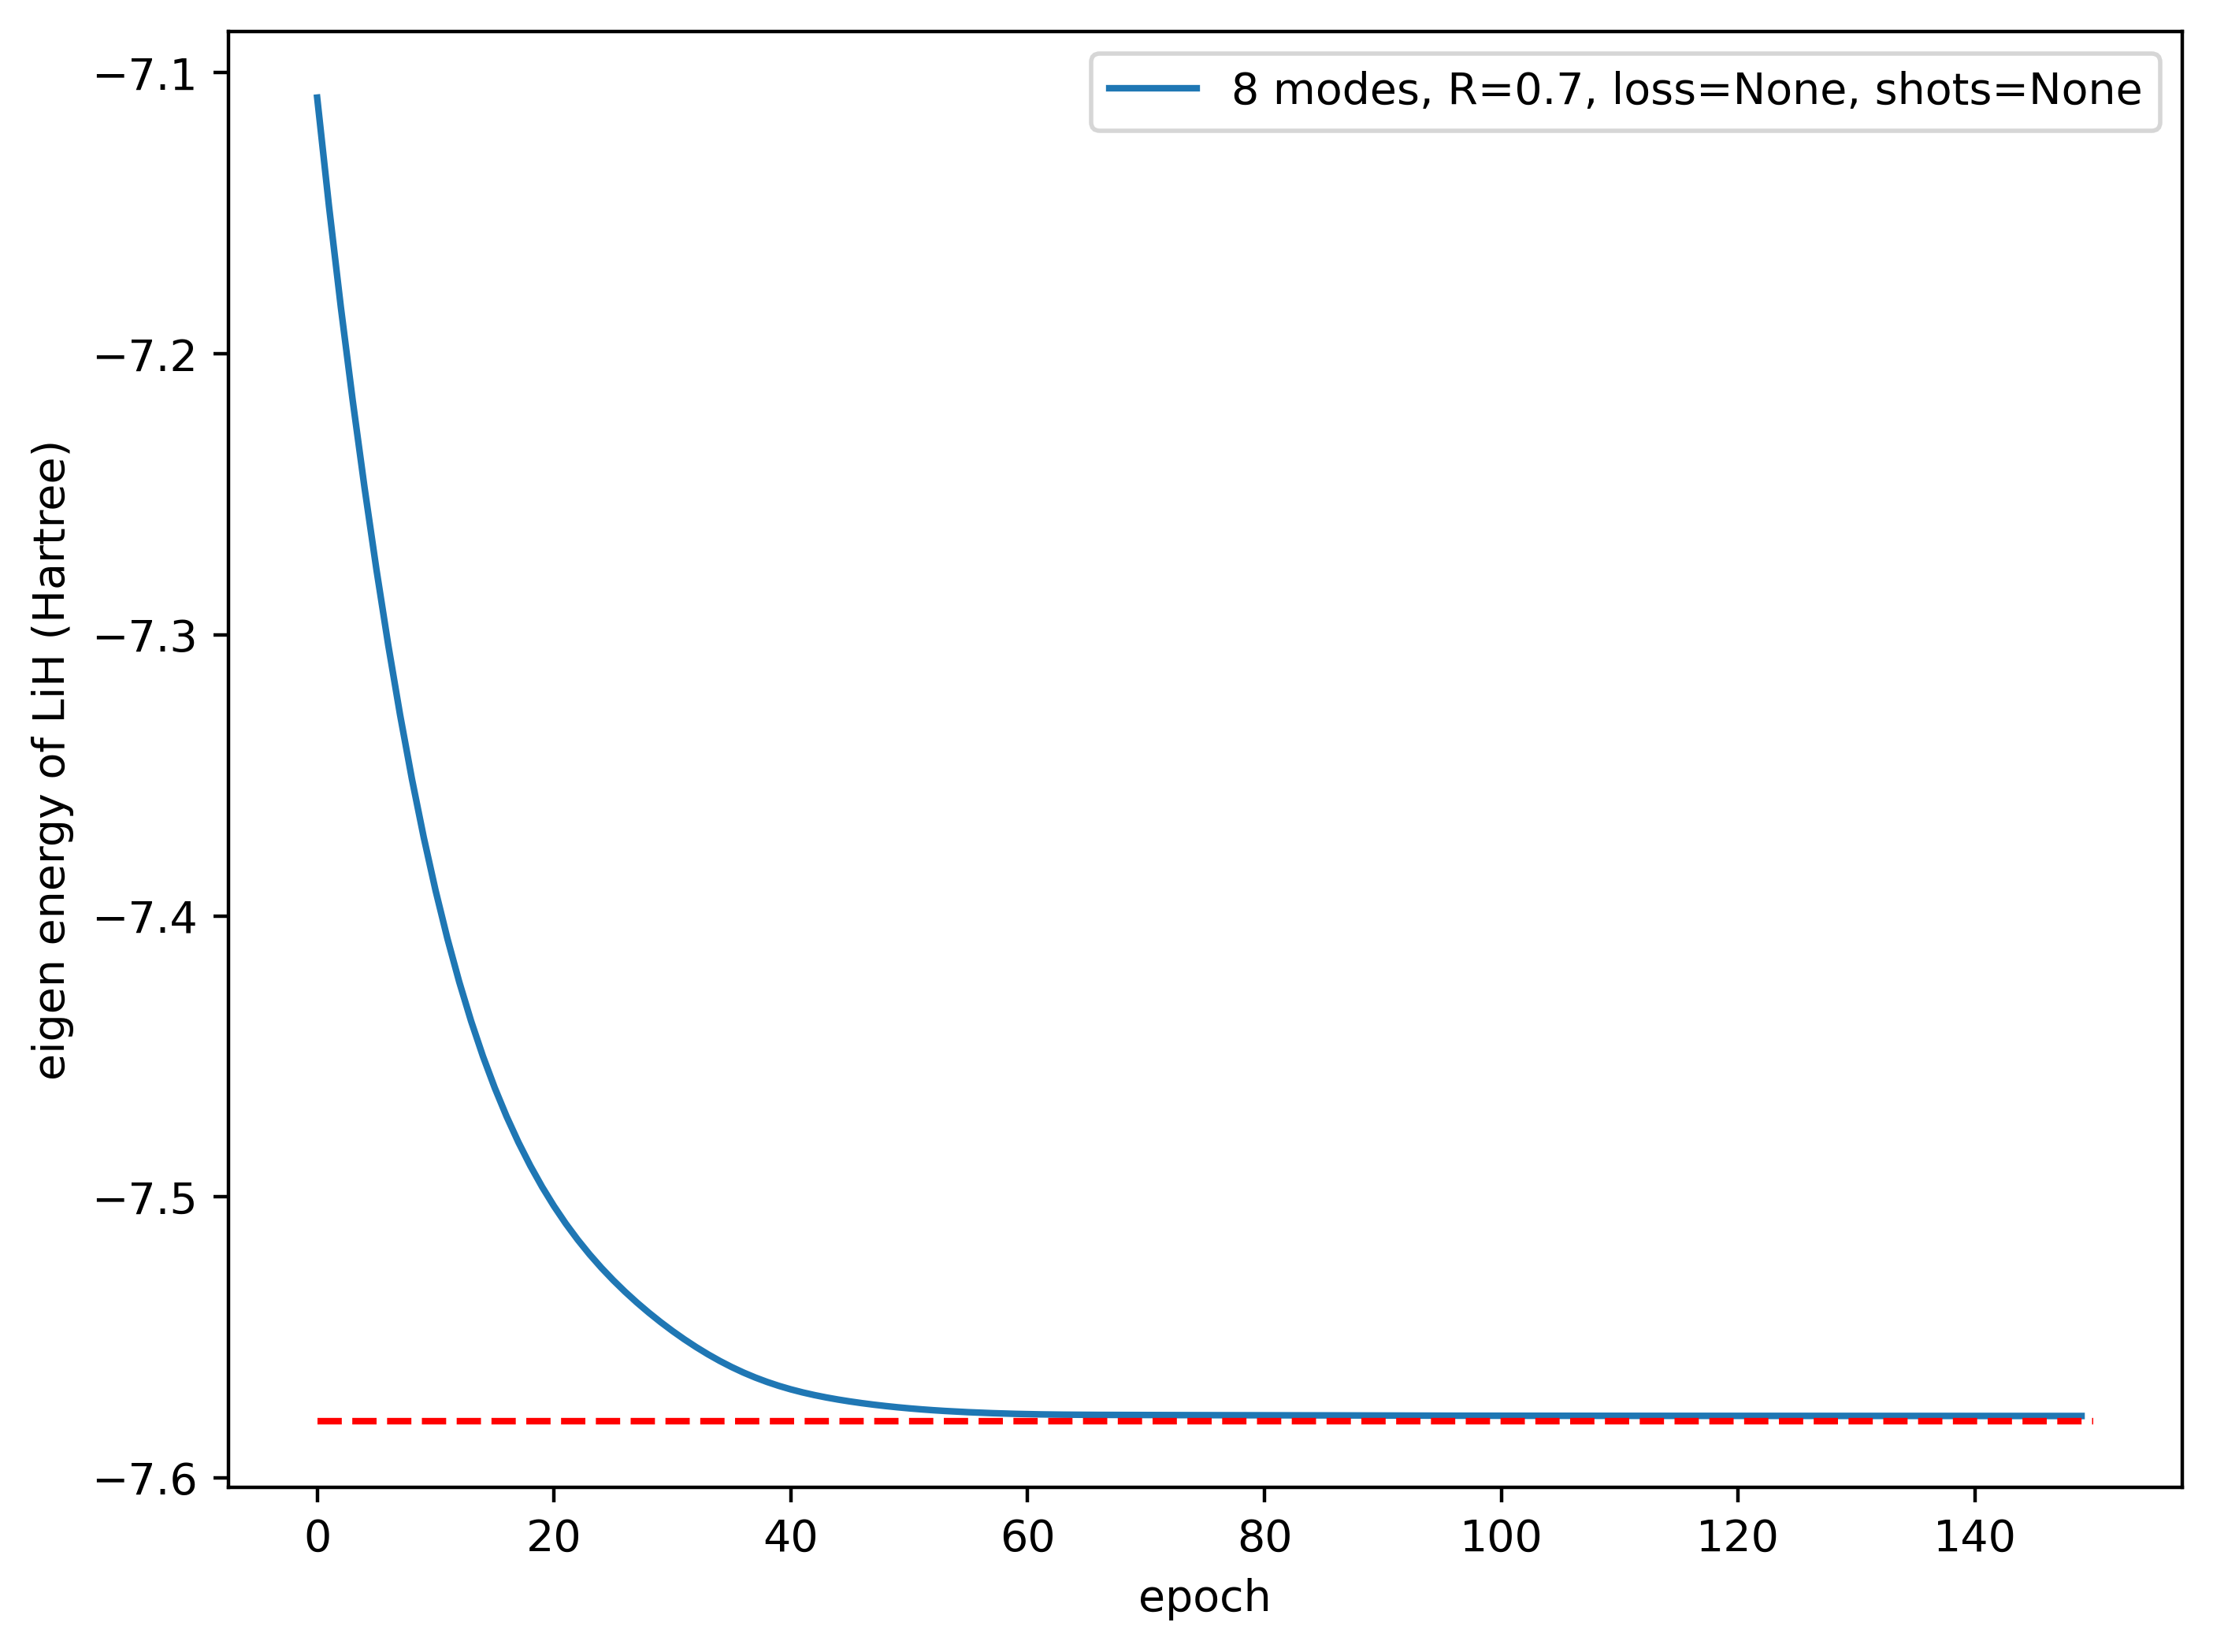

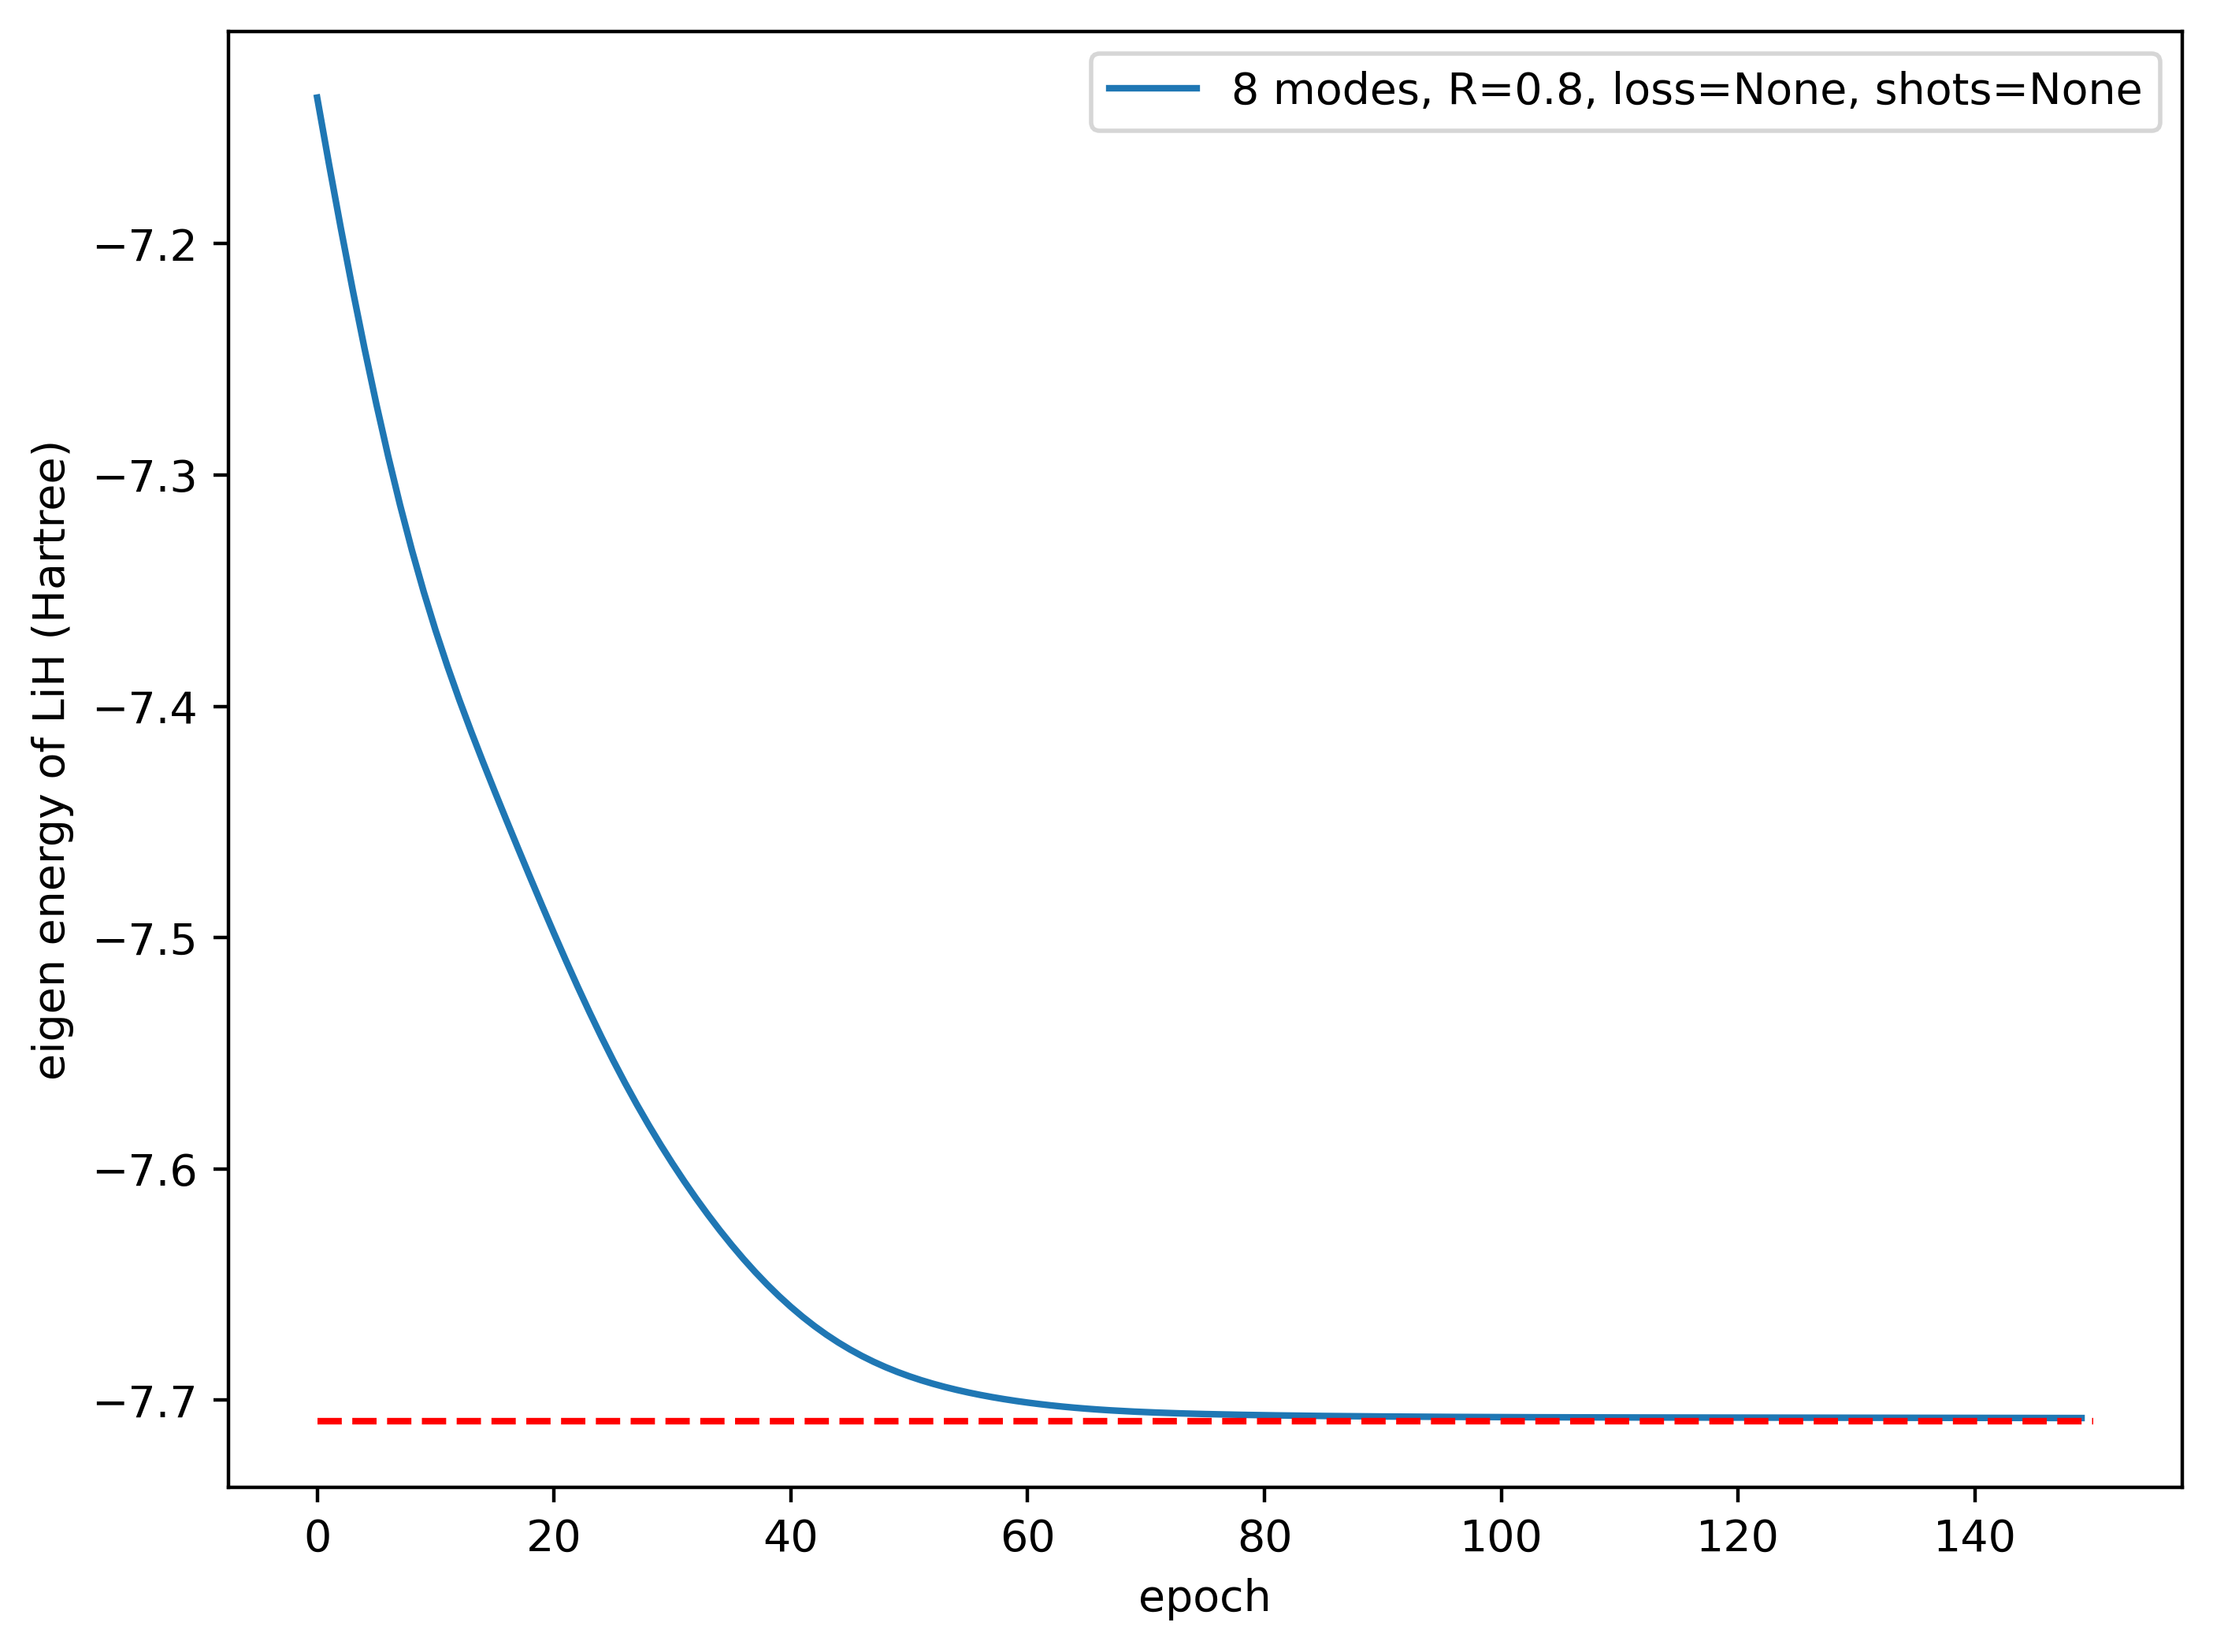

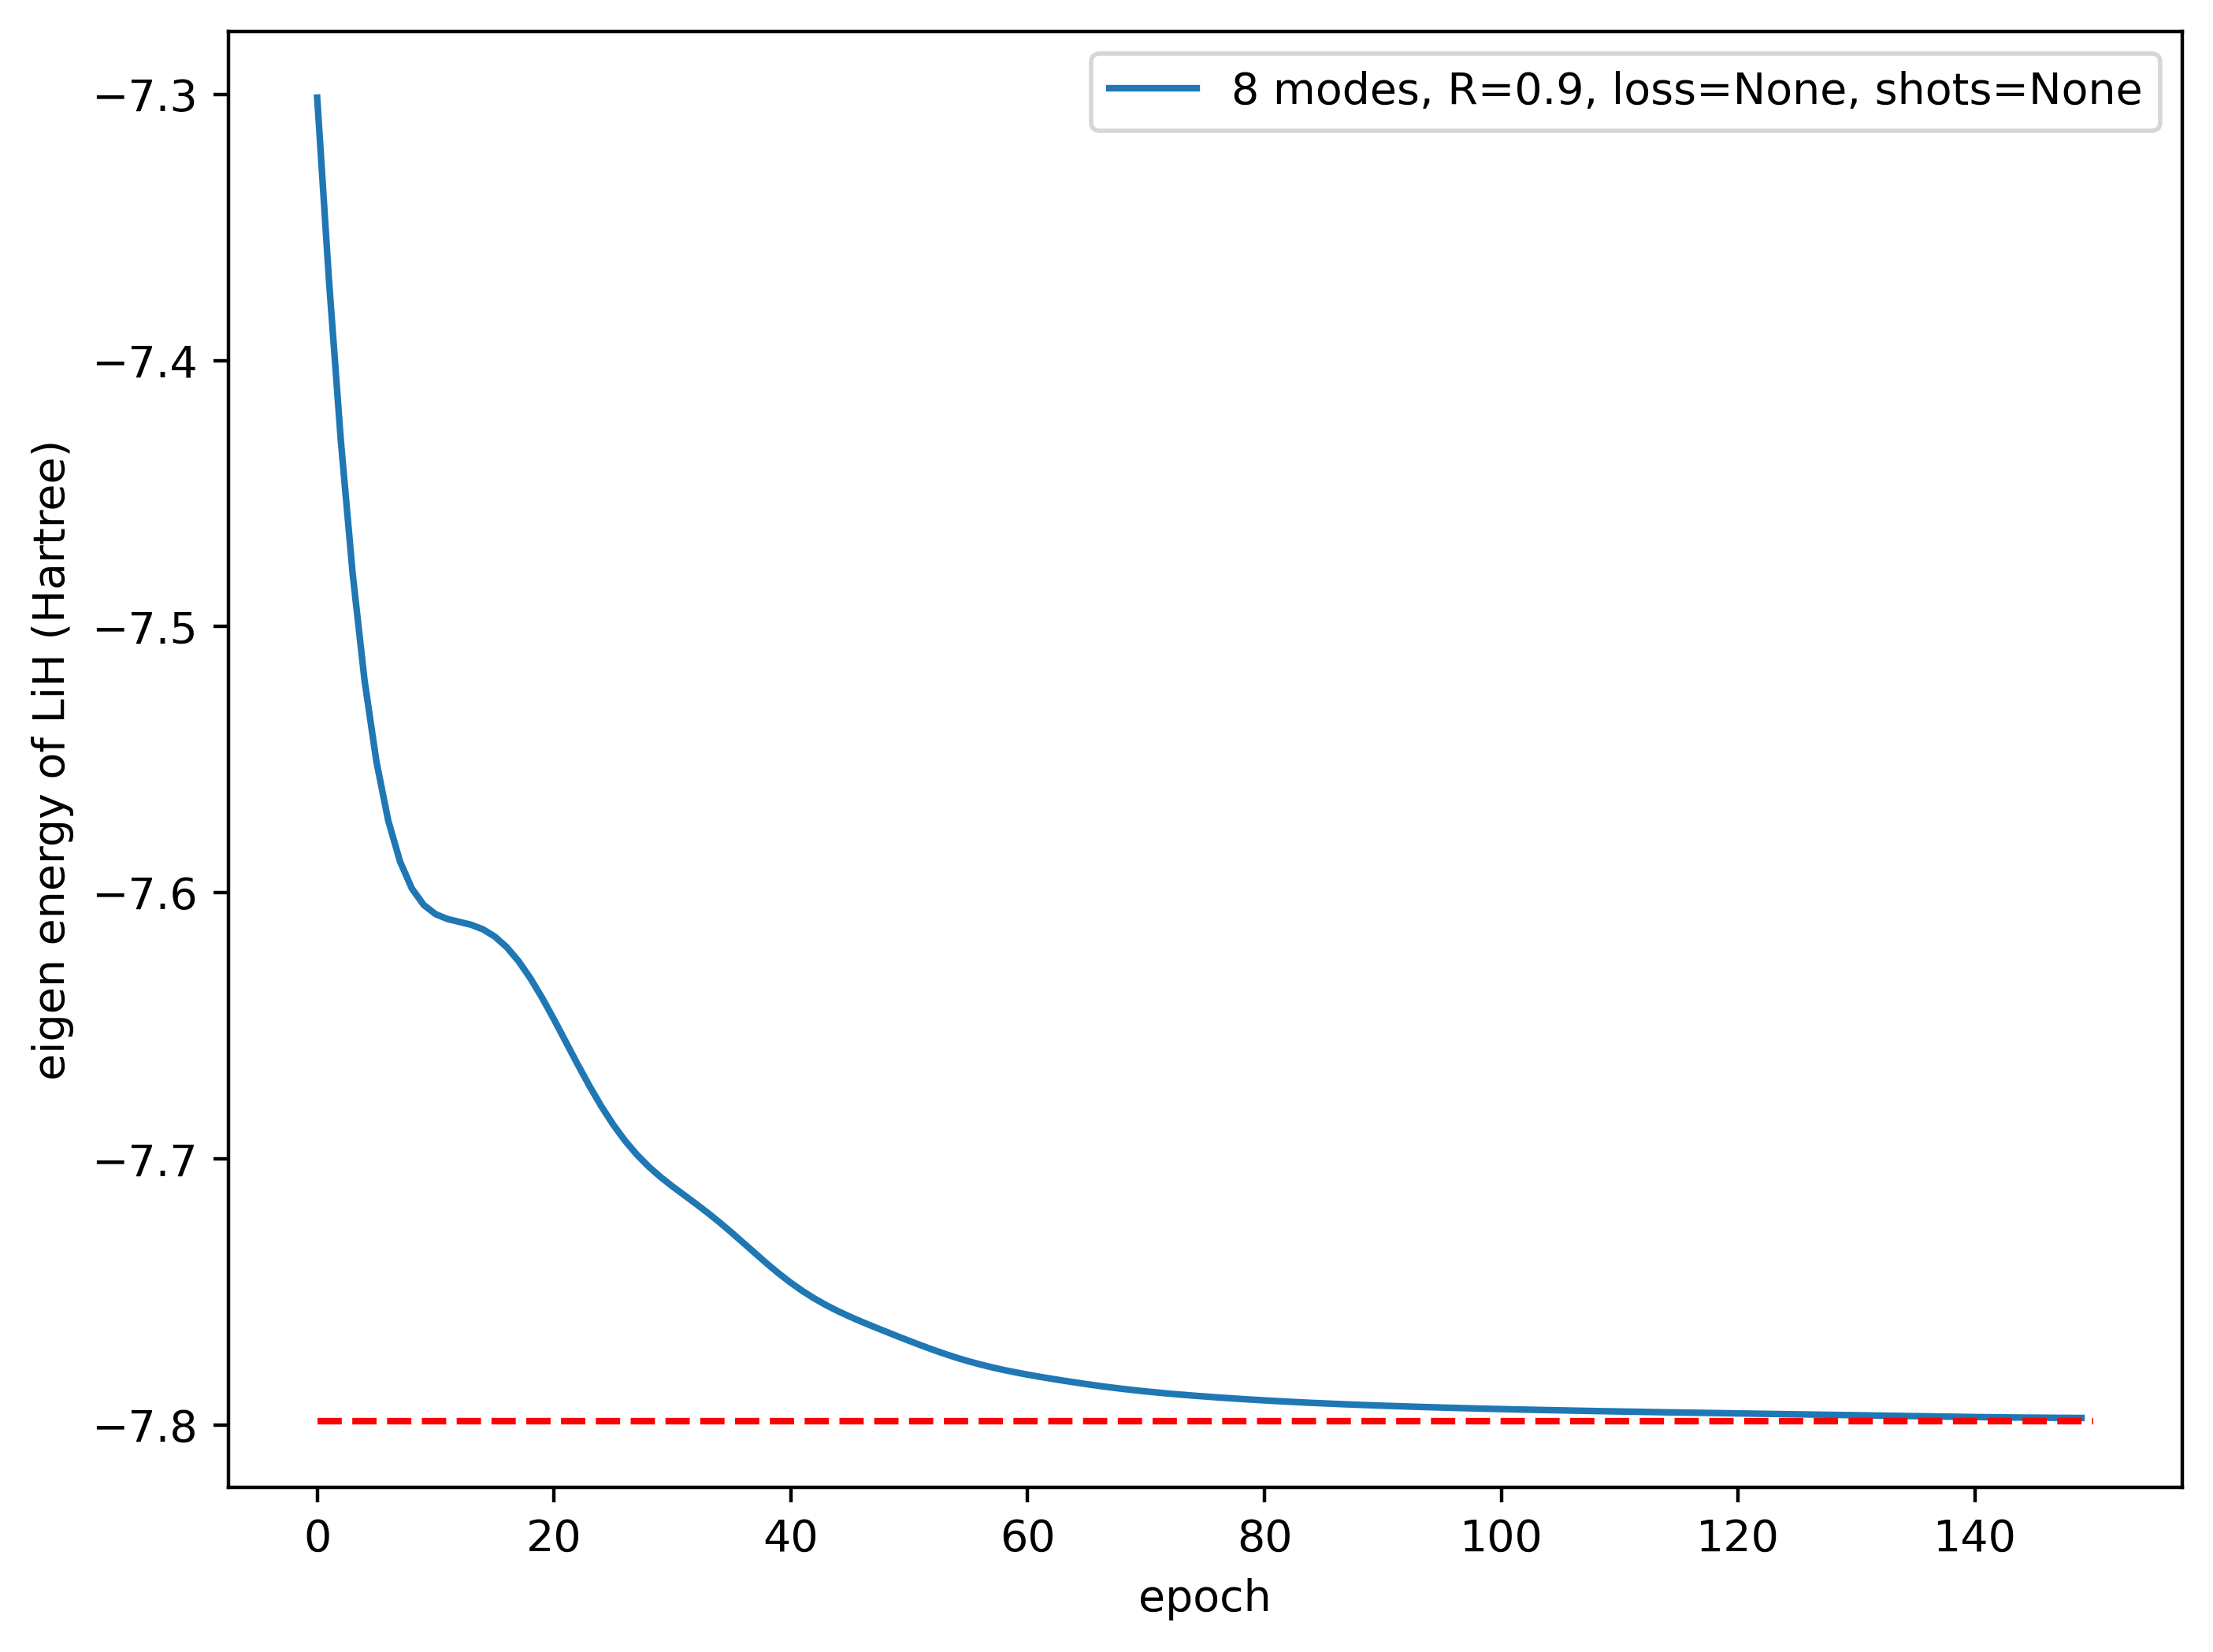

In [11]:
## 梯度下降法
n_subs = 2
shots_list = [50, 100, 500]
shots = None
all_loss = []

radius_list = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
# radius_list = [0.1]
for radius in radius_list:
    # radius = 0.2
    with open(f'data_lih/LiH_data_{radius}.pkl', 'rb') as f:
        dic = pickle.load(f)
    constant = dic['constant']
    pauli_list_full = dic['pauli_list']
    energy_full = dic['fci_energy']
    u_measure_list_q3_ts, idx_z_list_q3_ts, pauli_coef = get_measure_u(pauli_list_full)

    loss_all = []
    pauli_coef_ts = torch.tensor(pauli_coef)
    data = nn.Parameter(torch.rand(64) * 2 * torch.pi)
    lambdas = nn.Parameter(torch.rand(1, 3, dtype=torch.complex128))
    optimizer = torch.optim.Adam([data, lambdas], lr=2e-2)
    # print(u_measure_list_q3_ts.shape)
    for epoch in range(150):
        optimizer.zero_grad()
        test = compute_eigen_energy_measure_photonic_lih(
            models_q3_diag,
            models_q3_off_diag,
            n_subs,
            u_measure_list_q3_ts,
            idx_z_list_q3_ts,
            pauli_coef_ts,
            data,
            shots,
        )
        loss = test[0] + constant
        loss.backward()  # backpropagetion
        optimizer.step()  # update parameters
        loss_all.append(loss.detach())
        print(radius, epoch, loss, end='\r')

    all_loss.append(loss_all)

    plt.figure(figsize=(8, 6), dpi=400)
    plt.plot(range(len(loss_all)), loss_all, label=f'8 modes, R={radius}, loss={loss_db}, shots={shots}')
    plt.hlines(energy_full, 0, 150, ls='--', color='red')
    plt.legend()
    plt.xlabel('epoch')
    plt.ylabel('eigen energy of LiH (Hartree)')

3.630842648889124 2.6820088502228137
-3.20818574477686 -4.128724200288428
-5.044894665036592 -5.9581181204277875
-5.7823104238036 -6.711312207915317
-6.143032703268023 -7.122643610296507
-6.346696128267634 -7.393552184436494
-6.476678952629687 -7.579731757667254
-6.5685402691750285 -7.708995288126277
-6.638589093321304 -7.798451241458049


Text(0, 0.5, 'eigen energy of LiH (Hartree)')

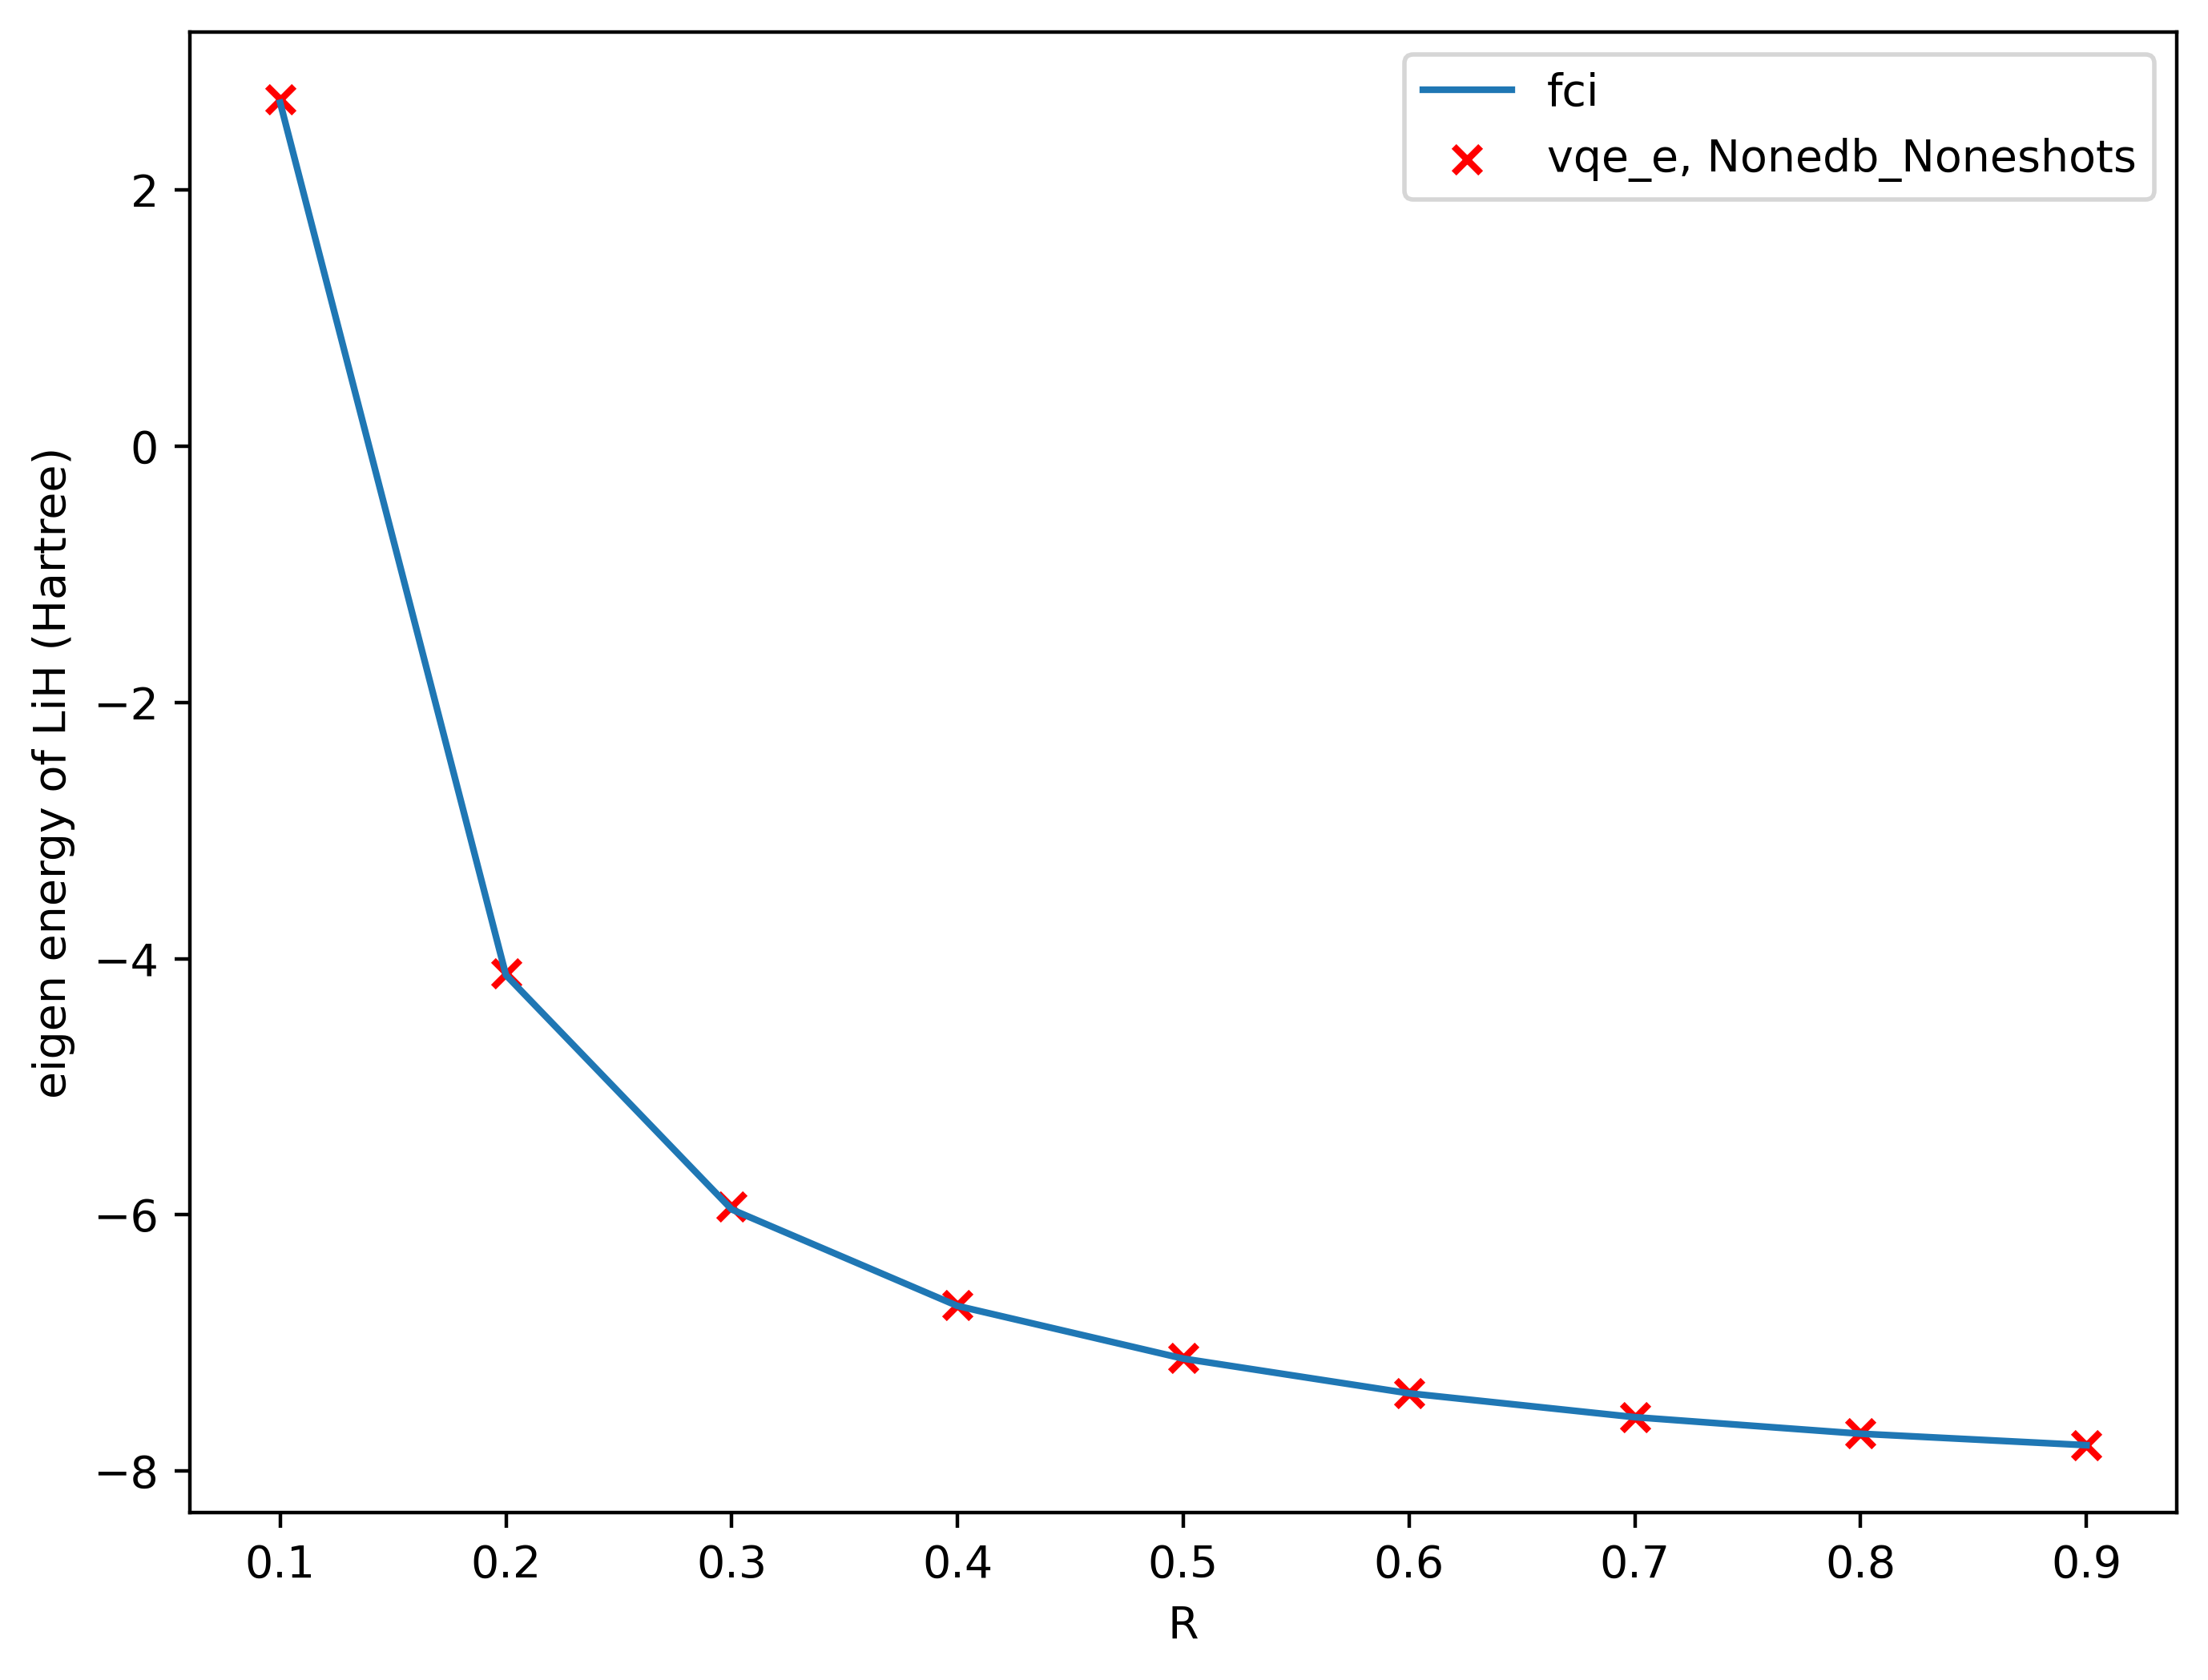

In [13]:
full_e = []
vqe_e = []

radius_list = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
for i in range(9):
    # radius = 0.2
    radius = radius_list[i]
    with open(f'data_lih/LiH_data_{radius}.pkl', 'rb') as f:
        dic = pickle.load(f)
    constant = dic['constant']
    pauli_list_full = dic['pauli_list']
    energy_full = dic['fci_energy']
    print(constant, energy_full)
    full_e.append(energy_full)
    vqe_e.append(all_loss[i][-1])

torch.save(torch.tensor(vqe_e), f'data_lih/opt_results_{loss_db}db_{shots}shots_3schimdt.pt')
plt.figure(figsize=(8, 6), dpi=400)
plt.plot(radius_list, full_e, label='fci')
plt.scatter(radius_list, vqe_e, marker='x', label=f'vqe_e, {loss_db}db_{shots}shots', color='red')

# plt.hlines(energy_full, 0, 100, ls='--', color='red')
plt.legend()
plt.xlabel('R')
plt.ylabel('eigen energy of LiH (Hartree)')